# GT Parameter Distribution — Normalization Strategy Study

This notebook explores the distribution of **all** Gaussian parameters (amplitude `a`, mean `μ`, standard deviation `σ`) across the full dataset.

**Key motivation:** many pixels carry no real Gaussian (near-zero amplitude), so their `μ` and `σ` values are meaningless — yet they dominate any global normalization. We need to understand:
1. How many "inactive" pixels exist, and how they distort each parameter's distribution.
2. Whether each parameter is Gaussian, log-normal, heavy-tailed, etc.
3. Which normalization strategy (z-score, min-max, robust/IQR, log1p+z) maps the active-pixel range cleanly to `[−1, 1]` or `[0, 1]` without being poisoned by background noise.


## 1 · Import Libraries & Configuration

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid", palette="muted")
%matplotlib inline

# ── Global configuration ─────────────────────────────────────────────────────
PATH           = "/ste/rnd/User/vice_vi/Dataset/clean_dataset/params/params_sig_k5/parameters_sig_k5.npy"
AMP_THRESHOLD  = 1e-2   # pixels with amplitude below this are treated as "inactive / background"
HALF_WINDOW    = 50     # SAR window half-width in samples (for flatness analysis)
SUBSAMPLE      = 200_000  # max points for scatter / hexbin to keep it fast
RNG            = np.random.default_rng(42)


## 2 · Load Parameter Array & Extract Channels

In [2]:
params = np.load(PATH, mmap_mode="r")
print(f"Shape  : {params.shape}   →   (C, H, W)")
print(f"Dtype  : {params.dtype}")
print(f"Sample (first 9 values of channel 0): {params[0].flat[:9]}")

# Channel layout: [a0, mu0, sig0,  a1, mu1, sig1, ...]
n_channels  = params.shape[0]
n_gaussians = n_channels // 3

amp_idx   = [3 * k     for k in range(n_gaussians)]
mu_idx    = [3 * k + 1 for k in range(n_gaussians)]
sigma_idx = [3 * k + 2 for k in range(n_gaussians)]

print(f"\nn_gaussians : {n_gaussians}")
print(f"amp channels   : {amp_idx}")
print(f"mu  channels   : {mu_idx}")
print(f"sig channels   : {sigma_idx}")


Shape  : (15, 15000, 3500)   →   (C, H, W)
Dtype  : float32
Sample (first 9 values of channel 0): [0.07066043 0.06710903 0.07425232 0.07697561 0.07641011 0.08407217
 0.08044377 0.07295728 0.07365967]

n_gaussians : 5
amp channels   : [0, 3, 6, 9, 12]
mu  channels   : [1, 4, 7, 10, 13]
sig channels   : [2, 5, 8, 11, 14]


## 3 · Amplitude — Pixel Activity Analysis

How many pixels are "real" (active) vs background (near-zero amplitude)?  
This directly determines how badly the background contaminates a global normalization.

  Gaussian   threshold    inactive %    active %
--------------------------------------------------
  g     1        1e-04         4.84%      95.16%
  g     1        1e-03         4.85%      95.15%
  g     1        1e-02         6.13%      93.87%
  g     1        1e-01        41.84%      58.16%
  g     2        1e-04        66.29%      33.71%
  g     2        1e-03        66.30%      33.70%
  g     2        1e-02        67.06%      32.94%
  g     2        1e-01        85.85%      14.15%
  g     3        1e-04        89.09%      10.91%
  g     3        1e-03        89.11%      10.89%
  g     3        1e-02        89.31%      10.69%
  g     3        1e-01        90.45%       9.55%
  g     4        1e-04        81.50%      18.50%
  g     4        1e-03        81.53%      18.47%
  g     4        1e-02        81.79%      18.21%
  g     4        1e-01        83.17%      16.83%
  g     5        1e-04        62.50%      37.50%
  g     5        1e-03        62.53%      37.47%
  g     5        1

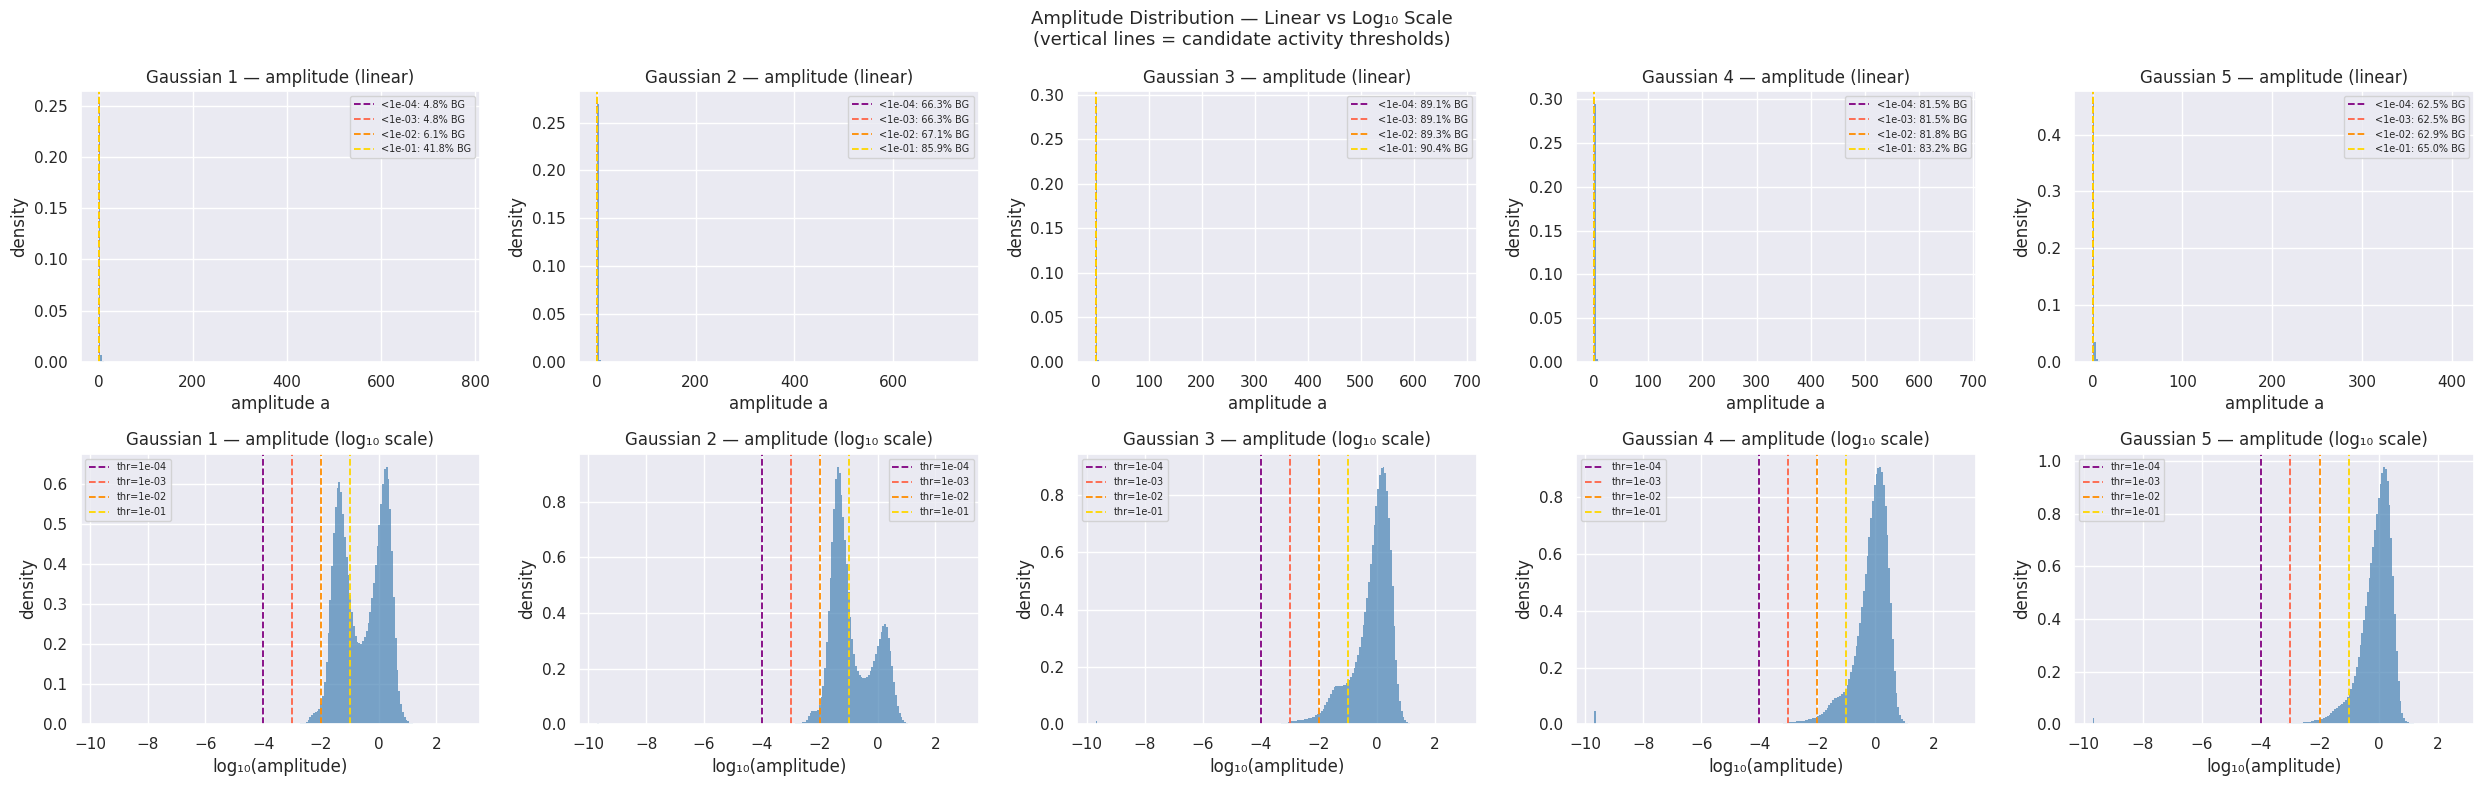

In [3]:
fig, axes = plt.subplots(2, n_gaussians, figsize=(5 * n_gaussians, 8))
if n_gaussians == 1:
    axes = axes.reshape(2, 1)

amp_thresholds = [1e-4, 1e-3, 1e-2, 0.1]
colors_thr = ["purple", "tomato", "darkorange", "gold"]

print(f"{'Gaussian':>10}  {'threshold':>10}  {'inactive %':>12}  {'active %':>10}")
print("-" * 50)

for k in range(n_gaussians):
    a = params[amp_idx[k]].reshape(-1)
    a = a[np.isfinite(a)]

    # Linear histogram
    ax_lin = axes[0, k]
    ax_lin.hist(a, bins=200, density=True, color="steelblue", alpha=0.7, edgecolor="none")
    for thr, col in zip(amp_thresholds, colors_thr):
        pct_inactive = 100.0 * (a < thr).mean()
        ax_lin.axvline(thr, color=col, lw=1.3, linestyle="--",
                       label=f"<{thr:.0e}: {pct_inactive:.1f}% BG")
        print(f"  g{k+1:>6}   {thr:>10.0e}  {pct_inactive:>11.2f}%  {100-pct_inactive:>9.2f}%")
    ax_lin.set_title(f"Gaussian {k+1} — amplitude (linear)")
    ax_lin.set_xlabel("amplitude a")
    ax_lin.set_ylabel("density")
    ax_lin.legend(fontsize=7)

    # Log-scale x-axis histogram — reveals the near-zero spike
    ax_log = axes[1, k]
    a_pos = a[a > 0]
    ax_log.hist(np.log10(a_pos + 1e-10), bins=200, density=True,
                color="steelblue", alpha=0.7, edgecolor="none")
    for thr, col in zip(amp_thresholds, colors_thr):
        ax_log.axvline(np.log10(thr), color=col, lw=1.3, linestyle="--", label=f"thr={thr:.0e}")
    ax_log.set_title(f"Gaussian {k+1} — amplitude (log₁₀ scale)")
    ax_log.set_xlabel("log₁₀(amplitude)")
    ax_log.set_ylabel("density")
    ax_log.legend(fontsize=7)

fig.suptitle("Amplitude Distribution — Linear vs Log₁₀ Scale\n(vertical lines = candidate activity thresholds)", fontsize=13)
fig.tight_layout()
plt.show()


## 4 · Separate Active vs Inactive Pixels

Split each channel into **active** (`amp > AMP_THRESHOLD`) and **inactive** populations.  
All downstream cells work on both, so we can see clearly how background pixels distort global statistics.

In [3]:
# Build per-Gaussian active/inactive masks and collect flat arrays for each parameter type
data = {}   # data[k] = {"amp": ..., "mu": ..., "sigma": ..., "mask_active": ...}

for k in range(n_gaussians):
    amp   = params[amp_idx[k]].reshape(-1).copy().astype(np.float64)
    mu    = params[mu_idx[k]].reshape(-1).copy().astype(np.float64)
    sigma = params[sigma_idx[k]].reshape(-1).copy().astype(np.float64)

    finite = np.isfinite(amp) & np.isfinite(mu) & np.isfinite(sigma)
    amp, mu, sigma = amp[finite], mu[finite], sigma[finite]

    active = amp > AMP_THRESHOLD
    data[k] = dict(amp=amp, mu=mu, sigma=sigma, active=active)

    n_total  = len(amp)
    n_active = active.sum()
    print(f"Gaussian {k+1}: total={n_total:,}  "
          f"active={n_active:,} ({100*n_active/n_total:.1f}%)  "
          f"inactive={n_total-n_active:,} ({100*(1-n_active/n_total):.1f}%)")


Gaussian 1: total=52,500,000  active=49,955,332 (95.2%)  inactive=2,544,668 (4.8%)
Gaussian 2: total=52,500,000  active=17,690,385 (33.7%)  inactive=34,809,615 (66.3%)
Gaussian 3: total=52,500,000  active=5,718,931 (10.9%)  inactive=46,781,069 (89.1%)
Gaussian 4: total=52,500,000  active=9,696,749 (18.5%)  inactive=42,803,251 (81.5%)
Gaussian 5: total=52,500,000  active=19,670,621 (37.5%)  inactive=32,829,379 (62.5%)


## 5 · Per-Parameter Descriptive Statistics

Side-by-side statistics for **all pixels** vs **active pixels** for each of `a`, `μ`, `σ`.  
Large differences between the two populations → normalization computed on all pixels will be off.

In [5]:
def _stats_row(arr):
    pcts = np.percentile(arr, [5, 25, 50, 75, 95, 99])
    return dict(mean=arr.mean(), std=arr.std(), min=arr.min(),
                p5=pcts[0], p25=pcts[1], median=pcts[2],
                p75=pcts[3], p95=pcts[4], p99=pcts[5], max=arr.max(),
                skew=float(stats.skew(arr)), kurt=float(stats.kurtosis(arr)))

header = f"{'stat':<8}" + "".join(f"{'ALL':>12}" + f"{'ACTIVE':>12}")
sep    = "-" * (8 + 24)

for k in range(n_gaussians):
    d = data[k]
    m = d["active"]
    print(f"\n{'═'*60}")
    print(f"  Gaussian {k+1}")
    print(f"{'═'*60}")
    for param_name, arr_all, arr_act in [
        ("amplitude a",  d["amp"],          d["amp"][m]),
        ("mean μ",       d["mu"],           d["mu"][m]),
        ("sigma σ",      d["sigma"],        d["sigma"][m]),
    ]:
        s_all = _stats_row(arr_all)
        s_act = _stats_row(arr_act)
        print(f"\n  ── {param_name} ──")
        print(f"  {'stat':<8}  {'ALL pixels':>14}  {'Active only':>14}")
        print(f"  {'-'*40}")
        for key in s_all:
            print(f"  {key:<8}  {s_all[key]:>14.4f}  {s_act[key]:>14.4f}")



════════════════════════════════════════════════════════════
  Gaussian 1
════════════════════════════════════════════════════════════

  ── amplitude a ──
  stat          ALL pixels     Active only
  ----------------------------------------
  mean              0.8763          0.9210
  std               2.1509          2.1957
  min               0.0000          0.0010
  p5                0.0038          0.0195
  p25               0.0429          0.0497
  median            0.2247          0.2995
  p75               1.3736          1.4426
  p95               3.1991          3.2531
  p99               5.2402          5.3192
  max             771.9399        771.9399
  skew            141.4988        139.7386
  kurt          38058.2434      36822.3625

  ── mean μ ──
  stat          ALL pixels     Active only
  ----------------------------------------
  mean             -5.0805         -5.3380
  std               3.4402          3.3238
  min             -20.0000        -20.0000
  p5      

## 6 · Histograms & KDE per Parameter (`a`, `μ`, `σ`)

Each subplot shows the **active-pixel** distribution.  
Grey shaded area in the background shows where the **full** (all-pixel) distribution sits — observe how much the background mass shifts things.

In [ ]:
param_meta = [
    ("amp",   "amplitude a",  "steelblue"),
    ("mu",    "mean μ",       "seagreen"),
    ("sigma", "sigma σ",      "darkorange"),
]

fig, axes = plt.subplots(3, n_gaussians, figsize=(5 * n_gaussians, 12), squeeze=False)

for row, (pkey, plabel, pcol) in enumerate(param_meta):
    for k in range(n_gaussians):
        ax = axes[row, k]
        d  = data[k]
        arr_all = d[pkey]
        arr_act = d[pkey][d["active"]]

        # All-pixel (background) — grey
        ax.hist(arr_all, bins=150, density=True, color="grey",
                alpha=0.3, edgecolor="none", label="all pixels")
        # Active only — coloured + KDE
        ax.hist(arr_act, bins=150, density=True, color=pcol,
                alpha=0.55, edgecolor="none", label="active")
        try:
            sns.kdeplot(arr_act, ax=ax, color=pcol, lw=1.8, label="_kde")
        except Exception:
            pass

        ax.axvline(arr_act.mean(),     color="navy", lw=1.4, linestyle="--",
                   label=f"mean={arr_act.mean():.3g}")
        ax.axvline(np.median(arr_act), color="teal", lw=1.4, linestyle=":",
                   label=f"med={np.median(arr_act):.3g}")

        ax.set_title(f"G{k+1} — {plabel}")
        ax.set_xlabel(plabel)
        ax.set_ylabel("density")
        ax.legend(fontsize=7, framealpha=0.85)

fig.suptitle("Histogram + KDE — active vs all pixels per parameter & Gaussian component", fontsize=13)
fig.tight_layout()
plt.show()


## 7 · Log-Scale & Transformed Distribution Views

Check whether **log1p** or **log** transforms make the distributions more Gaussian.  
Compute skewness and kurtosis before and after each transform to quantify the improvement.

In [ ]:
def _skew_kurt(arr):
    return float(stats.skew(arr)), float(stats.kurtosis(arr))

print(f"{'param':<12} {'gaussian':>4}  {'raw_skew':>10}  {'raw_kurt':>10}  {'log1p_skew':>12}  {'log1p_kurt':>12}")
print("-" * 70)

fig, axes = plt.subplots(3, n_gaussians * 2, figsize=(5 * n_gaussians * 2, 10), squeeze=False)

for row, (pkey, plabel, pcol) in enumerate(param_meta):
    for k in range(n_gaussians):
        d   = data[k]
        arr = d[pkey][d["active"]]

        # For amplitude: log1p makes sense (positive values)
        # For mu: can be negative → shift first; log1p(x - min + eps)
        # For sigma: positive → log1p
        eps = 1e-8
        if pkey == "mu":
            arr_shift  = arr - arr.min() + eps
            arr_log1p  = np.log1p(arr_shift)
            transform_label = "log1p(μ − min)"
        else:
            arr_log1p = np.log1p(np.maximum(arr, 0))
            transform_label = "log1p"

        sk_raw,  ku_raw  = _skew_kurt(arr)
        sk_log,  ku_log  = _skew_kurt(arr_log1p)
        print(f"{plabel:<12} G{k+1:>3}  {sk_raw:>10.3f}  {ku_raw:>10.3f}  {sk_log:>12.3f}  {ku_log:>12.3f}")

        col_raw = k * 2
        col_log = k * 2 + 1

        # Raw
        ax0 = axes[row, col_raw]
        ax0.hist(arr, bins=150, density=True, color=pcol, alpha=0.6, edgecolor="none")
        try:
            sns.kdeplot(arr, ax=ax0, color="navy", lw=1.5)
        except Exception:
            pass
        ax0.set_title(f"G{k+1} {plabel} — raw\nskew={sk_raw:.2f}  kurt={ku_raw:.2f}", fontsize=8)
        ax0.set_xlabel(plabel)

        # Transformed
        ax1 = axes[row, col_log]
        ax1.hist(arr_log1p, bins=150, density=True, color=pcol, alpha=0.6, edgecolor="none")
        try:
            sns.kdeplot(arr_log1p, ax=ax1, color="navy", lw=1.5)
        except Exception:
            pass
        ax1.set_title(f"G{k+1} {plabel} — {transform_label}\nskew={sk_log:.2f}  kurt={ku_log:.2f}", fontsize=8)
        ax1.set_xlabel(transform_label)

fig.suptitle("Raw vs log1p-transformed distributions (active pixels)", fontsize=13)
fig.tight_layout()
plt.show()


## 8 · Cross-Parameter Joint Distributions

2-D joint plots: `(a vs σ)`, `(a vs μ)`, `(μ vs σ)` for each Gaussian component.  
Correlations between parameters mean that independent per-channel normalization may be inconsistent.

In [ ]:
pairs = [
    ("amp", "sigma", "amplitude a", "sigma σ",  "steelblue"),
    ("amp", "mu",    "amplitude a", "mean μ",    "seagreen"),
    ("mu",  "sigma", "mean μ",      "sigma σ",   "darkorange"),
]

for k in range(n_gaussians):
    d    = data[k]
    m    = d["active"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (xk, yk, xl, yl, col) in zip(axes, pairs):
        x = d[xk][m]
        y = d[yk][m]

        # Subsample for speed
        n = len(x)
        idx = RNG.choice(n, size=min(SUBSAMPLE, n), replace=False)
        x_s, y_s = x[idx], y[idx]

        hb = ax.hexbin(x_s, y_s, gridsize=60, cmap="Blues", mincnt=1, bins="log")
        plt.colorbar(hb, ax=ax, label="log10(count)")
        r, p = stats.pearsonr(x_s, y_s)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"G{k+1}: {xl} vs {yl}\nPearson r={r:.3f}  (p={p:.1e})")

    fig.suptitle(f"Gaussian {k+1} — Joint Distributions (active pixels, subsampled)", fontsize=12)
    fig.tight_layout()
    plt.show()


## 9 · Normalization Strategy Comparison

For each parameter we test four strategies on the **active-pixel** distribution:

| Strategy | Formula | Good when |
|---|---|---|
| **z-score** | `(x − μ) / σ` | data is roughly Gaussian |
| **min-max** | `(x − min) / (max − min)` | bounded range, no outliers |
| **Robust / IQR** | `(x − median) / IQR` | heavy tails / outliers |
| **log1p + z-score** | `z-score(log1p(x))` | right-skewed, log-normal |

We then look at the normalized range and the fraction of values that fall outside `[−3, 3]` (saturated neurons).


══════════════════════════════════════════════════════════════════════
  Parameter: amplitude a
  gaussian      strategy       min       max        p1       p99      sat%
  ------------------------------------------------------------------
        G1       z-score     -0.42    351.15    -0.416     2.003     0.32%
        G1       min-max      0.00      1.00     0.000     0.007     0.00%
        G1    robust-IQR     -0.21    553.98    -0.209     3.604     1.78%
        G1       log1p+z     -0.95     11.92    -0.941     2.612     0.46%
        G2       z-score     -0.31    404.63    -0.308     2.279     0.42%
        G2       min-max      0.00      1.00     0.000     0.006     0.00%
        G2    robust-IQR     -0.14   1387.81    -0.127     8.740    12.26%
        G2       log1p+z     -0.69     13.89    -0.681     3.154     1.34%
        G3       z-score     -0.82    404.78    -0.817     2.783     0.79%
        G3       min-max      0.00      1.00     0.000     0.009     0.00%
        G

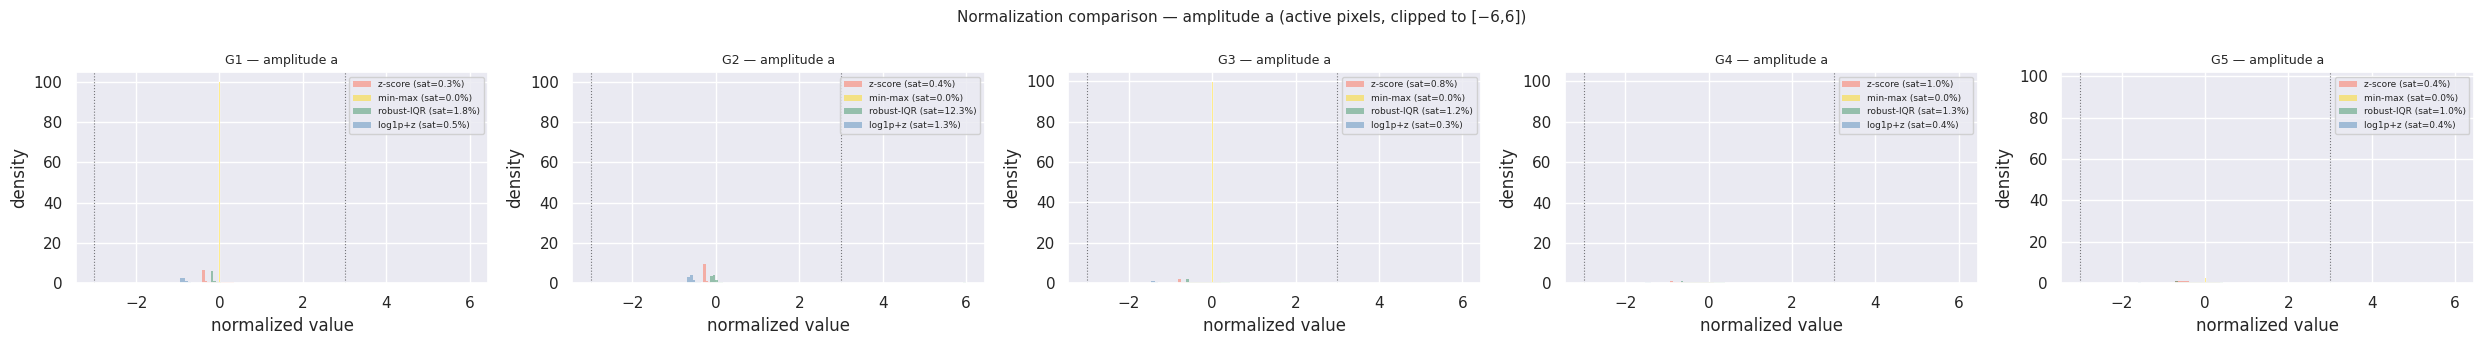


══════════════════════════════════════════════════════════════════════
  Parameter: mean μ
  gaussian      strategy       min       max        p1       p99      sat%
  ------------------------------------------------------------------
        G1       z-score     -4.41     20.02    -3.604     1.444     2.72%
        G1       min-max      0.00      1.00     0.033     0.240     0.00%
        G1    robust-IQR     -4.40     19.80    -3.600     1.400     2.69%
        G1       log1p+z     -8.54      5.33    -4.437     0.955     3.00%
        G2       z-score     -2.52     10.55    -1.032     4.017     2.89%
        G2       min-max      0.00      1.00     0.114     0.500     0.00%
        G2    robust-IQR     -5.75     27.25    -2.000    10.750    12.50%
        G2       log1p+z    -10.04      5.82    -1.561     3.413     2.34%
        G3       z-score     -2.31      3.91    -1.664     2.670     0.21%
        G3       min-max      0.00      1.00     0.104     0.800     0.00%
        G3    

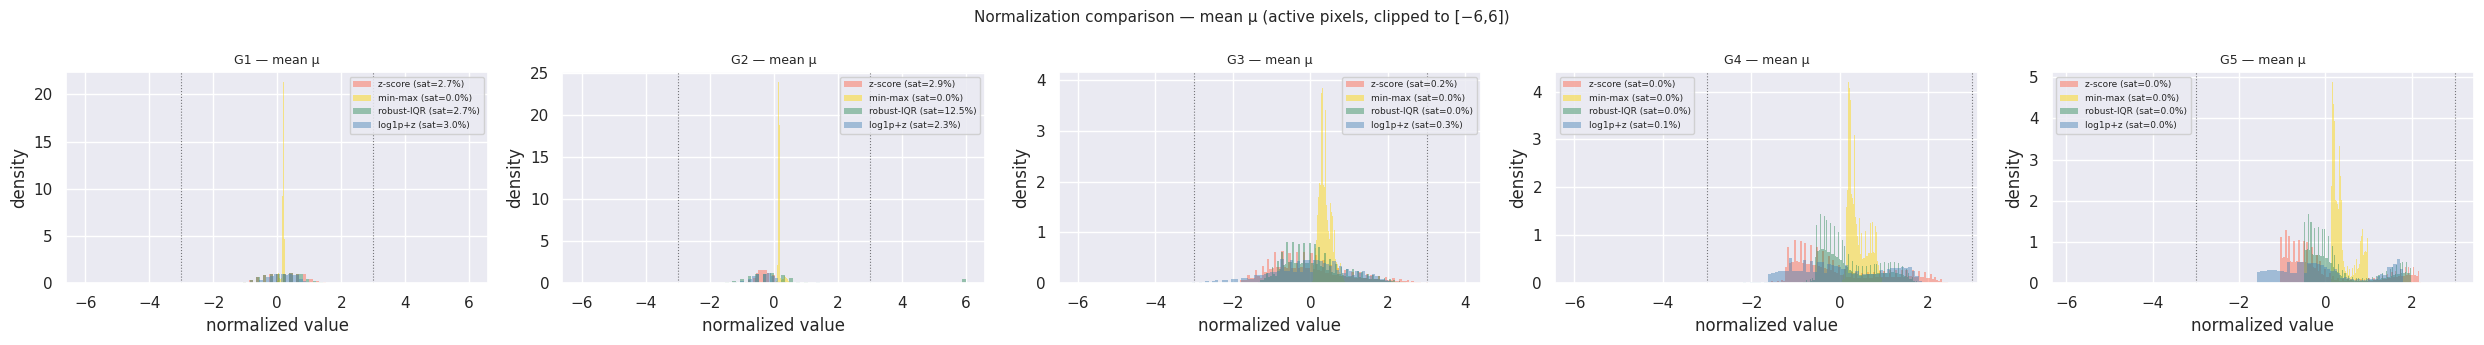


══════════════════════════════════════════════════════════════════════
  Parameter: sigma σ
  gaussian      strategy       min       max        p1       p99      sat%
  ------------------------------------------------------------------
        G1       z-score     -0.75     29.89    -0.748     3.691     1.67%
        G1       min-max      0.00      1.00     0.000     0.145     0.00%
        G1    robust-IQR     -0.47     32.45    -0.471     4.299     2.54%
        G1       log1p+z     -1.10      7.32    -1.099     3.000     1.00%
        G2       z-score     -0.45     29.53    -0.448     3.891     2.02%
        G2       min-max      0.00      1.00     0.000     0.145     0.00%
        G2    robust-IQR     -0.01     62.57    -0.015     9.044    10.86%
        G2       log1p+z     -0.58      7.48    -0.584     3.338     1.75%
        G3       z-score     -0.85     18.69    -0.851     3.222     1.23%
        G3       min-max      0.00      1.00     0.000     0.209     0.00%
        G3   

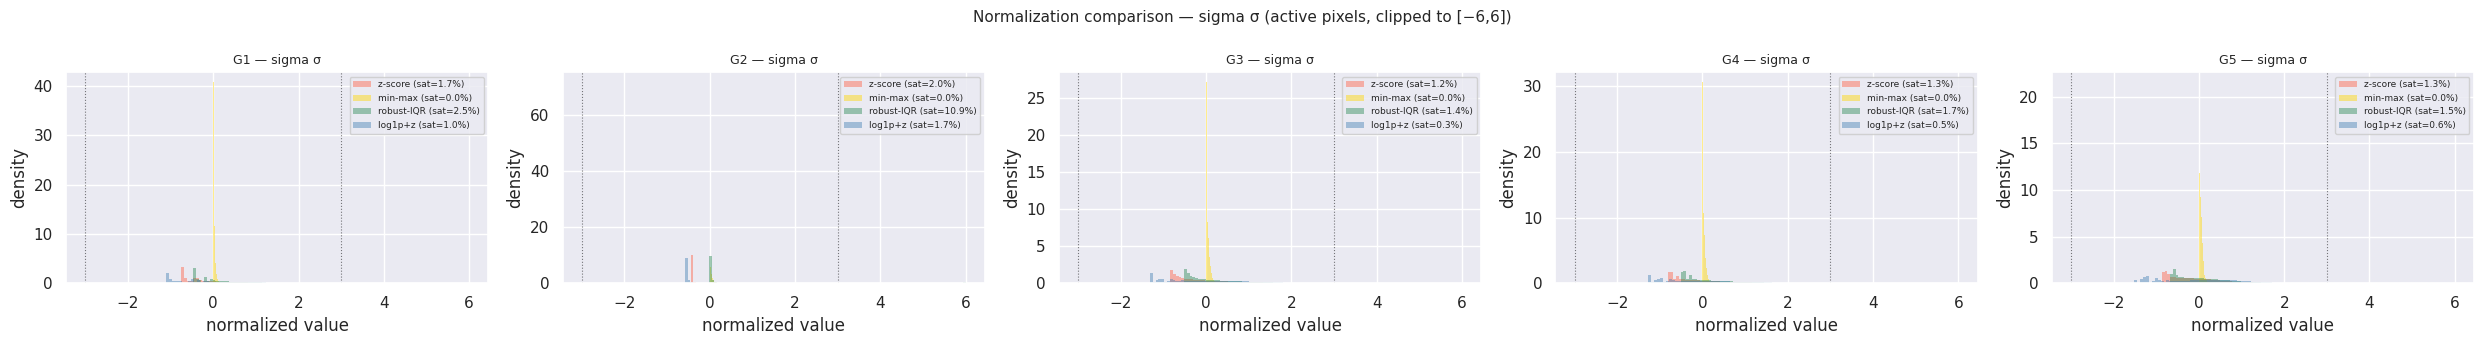

In [4]:
def apply_normalizations(arr, label=""):
    eps = 1e-8
    results = {}

    # z-score
    mu_, std_ = arr.mean(), arr.std()
    results["z-score"] = (arr - mu_) / (std_ + eps)

    # min-max
    lo, hi = arr.min(), arr.max()
    results["min-max"] = (arr - lo) / (hi - lo + eps)

    # robust IQR
    q25, q75 = np.percentile(arr, [25, 75])
    iqr = q75 - q25
    results["robust-IQR"] = (arr - np.median(arr)) / (iqr + eps)

    # log1p + z-score  (shift for possibly negative μ)
    arr_shift = arr - arr.min() + eps if arr.min() < 0 else arr
    arr_log   = np.log1p(arr_shift)
    mu_l, std_l = arr_log.mean(), arr_log.std()
    results["log1p+z"] = (arr_log - mu_l) / (std_l + eps)

    return results


def _saturation(arr, lo=-3, hi=3):
    return 100.0 * ((arr < lo) | (arr > hi)).mean()


strategy_names = ["z-score", "min-max", "robust-IQR", "log1p+z"]
colors_s = ["tomato", "gold", "seagreen", "steelblue"]

for pkey, plabel in [("amp", "amplitude a"), ("mu", "mean μ"), ("sigma", "sigma σ")]:
    print(f"\n{'═'*70}")
    print(f"  Parameter: {plabel}")
    print(f"  {'gaussian':>8}  {'strategy':>12}  {'min':>8}  {'max':>8}  {'p1':>8}  {'p99':>8}  {'sat%':>8}")
    print(f"  {'-'*66}")

    fig, axes = plt.subplots(1, n_gaussians, figsize=(5 * n_gaussians, 3.5), squeeze=False)

    for k in range(n_gaussians):
        d   = data[k]
        arr = d[pkey][d["active"]]
        norms = apply_normalizations(arr)
        ax = axes[0, k]

        for sname, scol in zip(strategy_names, colors_s):
            normed = norms[sname]
            sat    = _saturation(normed)
            p1, p99 = np.percentile(normed, [1, 99])
            print(f"  {'G'+str(k+1):>8}  {sname:>12}  {normed.min():>8.2f}  {normed.max():>8.2f}  "
                  f"{p1:>8.3f}  {p99:>8.3f}  {sat:>7.2f}%")

            # Clip for plotting readability
            clipped = np.clip(normed, -6, 6)
            ax.hist(clipped, bins=100, density=True, alpha=0.45, color=scol,
                    edgecolor="none", label=f"{sname} (sat={sat:.1f}%)")

        ax.set_title(f"G{k+1} — {plabel}", fontsize=9)
        ax.set_xlabel("normalized value")
        ax.set_ylabel("density")
        ax.axvline(-3, color="black", lw=0.8, linestyle=":", alpha=0.5)
        ax.axvline( 3, color="black", lw=0.8, linestyle=":", alpha=0.5)
        ax.legend(fontsize=6.5, framealpha=0.85)

    fig.suptitle(f"Normalization comparison — {plabel} (active pixels, clipped to [−6,6])", fontsize=11)
    fig.tight_layout()
    plt.show()


## 10 · Per-Gaussian Component Breakdown

Compare each Gaussian component side-by-side with **histogram + boxplot + CDF** to check:
- Are parameters from different components compatible? (if yes → shared normalization is fine)
- Are there systematic differences in scale or location between components?

/tmp/ipykernel_3826978/1453570072.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/tmp/ipykernel_3826978/1453570072.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/vice_vi/.conda/envs/dlr-cu12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


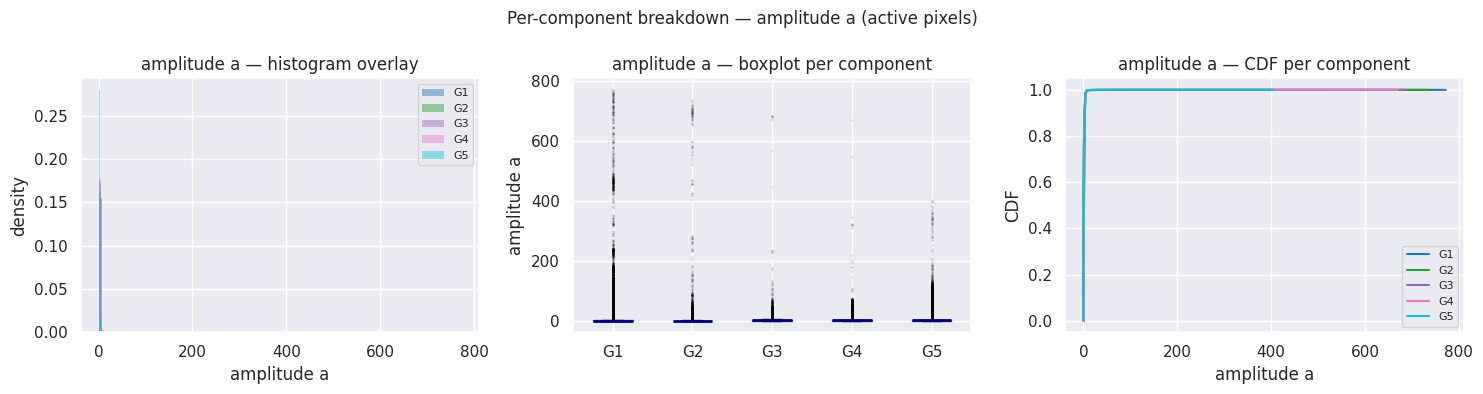

/tmp/ipykernel_3826978/1453570072.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/tmp/ipykernel_3826978/1453570072.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/vice_vi/.conda/envs/dlr-cu12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


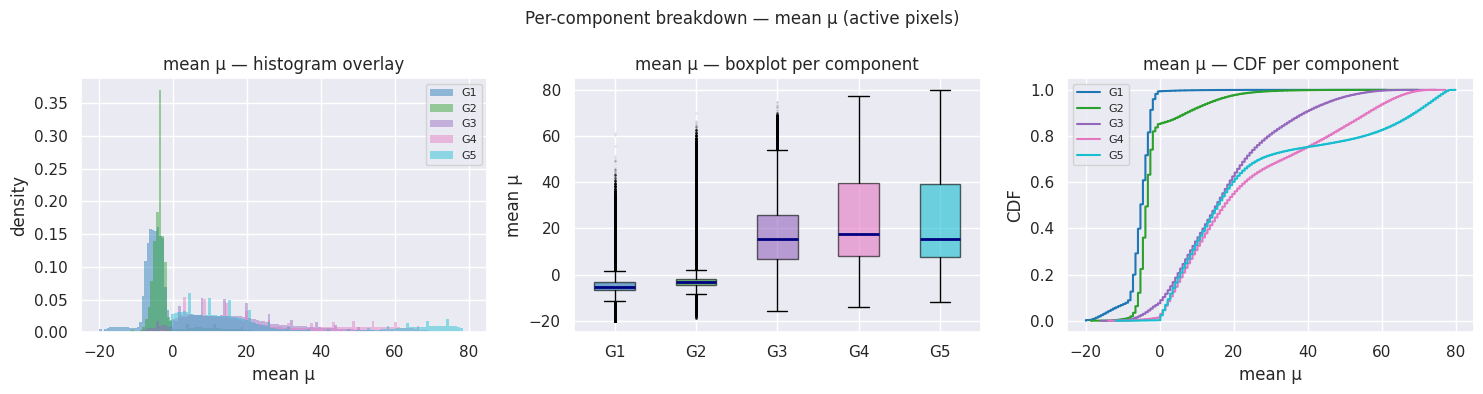

/tmp/ipykernel_3826978/1453570072.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/tmp/ipykernel_3826978/1453570072.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/vice_vi/.conda/envs/dlr-cu12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


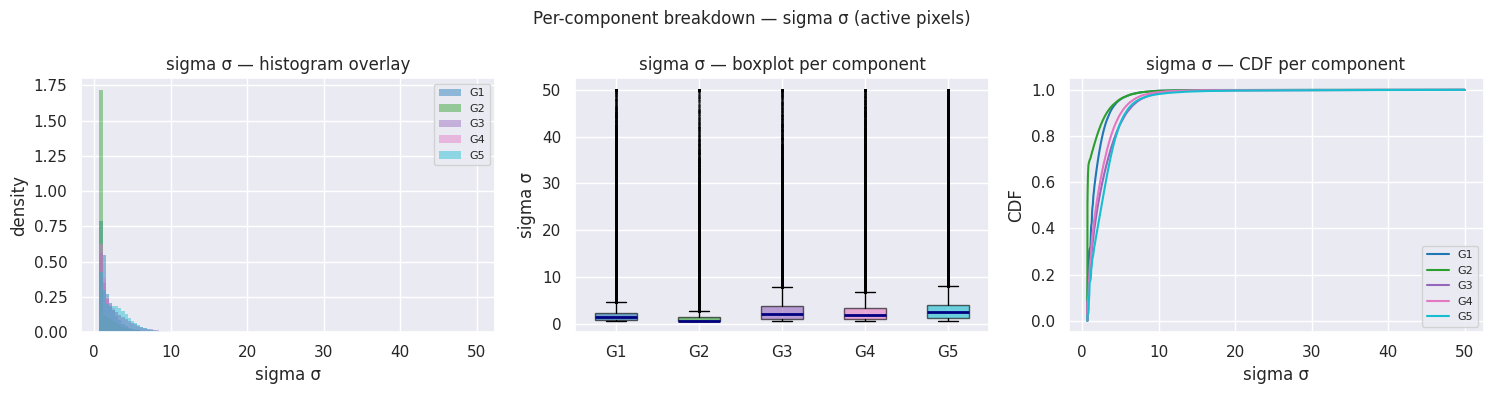

In [5]:
component_colors = plt.cm.tab10(np.linspace(0, 0.9, n_gaussians))

for pkey, plabel in [("amp", "amplitude a"), ("mu", "mean μ"), ("sigma", "sigma σ")]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ax_hist, ax_box, ax_cdf = axes

    box_data   = []
    box_labels = []

    for k in range(n_gaussians):
        d   = data[k]
        arr = d[pkey][d["active"]]
        col = component_colors[k]

        # Histogram overlay
        ax_hist.hist(arr, bins=120, density=True, alpha=0.45,
                     color=col, edgecolor="none", label=f"G{k+1}")

        # Boxplot data
        box_data.append(arr)
        box_labels.append(f"G{k+1}")

        # CDF
        s   = np.sort(arr)
        cdf = np.arange(1, len(s) + 1) / len(s)
        ax_cdf.plot(s, cdf, color=col, lw=1.5, label=f"G{k+1}")

    # Boxplot
    bp = ax_box.boxplot(
        box_data, labels=box_labels, patch_artist=True, notch=False,
        flierprops=dict(marker=".", markersize=1, alpha=0.15),
        medianprops=dict(color="navy", linewidth=2),
    )
    for patch, col in zip(bp["boxes"], component_colors):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)

    ax_hist.set_title(f"{plabel} — histogram overlay")
    ax_hist.set_xlabel(plabel)
    ax_hist.set_ylabel("density")
    ax_hist.legend(fontsize=8)

    ax_box.set_title(f"{plabel} — boxplot per component")
    ax_box.set_ylabel(plabel)

    ax_cdf.set_title(f"{plabel} — CDF per component")
    ax_cdf.set_xlabel(plabel)
    ax_cdf.set_ylabel("CDF")
    ax_cdf.legend(fontsize=8)

    fig.suptitle(f"Per-component breakdown — {plabel} (active pixels)", fontsize=12)
    fig.tight_layout()
    plt.show()


## 11 · Summary & Normalization Recommendation

Print a consolidated recommendation table based on the observed skewness, kurtosis, and saturation rates from section 9.

In [6]:
print("=" * 80)
print("  NORMALIZATION STRATEGY RECOMMENDATION SUMMARY")
print("=" * 80)
print(f"  Active-pixel threshold : amp > {AMP_THRESHOLD}")
print()
print(f"  {'param':<14}  {'skew (mean over G)':>20}  {'kurt (mean)':>12}  {'recommended strategy'}")
print(f"  {'-'*72}")

for pkey, plabel in [("amp", "amplitude a"), ("mu", "mean μ"), ("sigma", "sigma σ")]:
    skews, kurts, sat_z, sat_log = [], [], [], []
    for k in range(n_gaussians):
        d   = data[k]
        arr = d[pkey][d["active"]]
        skews.append(float(stats.skew(arr)))
        kurts.append(float(stats.kurtosis(arr)))
        norms = apply_normalizations(arr)
        sat_z.append(_saturation(norms["z-score"]))
        sat_log.append(_saturation(norms["log1p+z"]))

    mean_skew = np.mean(skews)
    mean_kurt = np.mean(kurts)
    mean_sat_z   = np.mean(sat_z)
    mean_sat_log = np.mean(sat_log)

    # Heuristic recommendation
    if abs(mean_skew) > 1.5 and mean_sat_log < mean_sat_z:
        rec = f"log1p + z-score  (sat z={mean_sat_z:.1f}% → log={mean_sat_log:.1f}%)"
    elif abs(mean_skew) > 0.8:
        rec = f"robust IQR       (heavy tails, skew={mean_skew:.2f})"
    else:
        rec = f"z-score          (near-Gaussian, skew={mean_skew:.2f})"

    print(f"  {plabel:<14}  {mean_skew:>20.3f}  {mean_kurt:>12.3f}  {rec}")

print()
print("  Notes:")
print("  • Always compute normalization stats from ACTIVE pixels only.")
print("  • Background (inactive) pixels should be zeroed / masked before computing stats.")
print("  • If components share compatible distributions, a single shared normalizer per")
print("    parameter type is fine; otherwise use per-component normalizers.")
print("=" * 80)


  NORMALIZATION STRATEGY RECOMMENDATION SUMMARY
  Active-pixel threshold : amp > 0.001

  param             skew (mean over G)   kurt (mean)  recommended strategy
  ------------------------------------------------------------------------
  amplitude a                  103.810     32524.356  log1p + z-score  (sat z=0.6% → log=0.6%)
  mean μ                         0.835         3.097  robust IQR       (heavy tails, skew=0.84)
  sigma σ                        5.169        68.441  log1p + z-score  (sat z=1.5% → log=0.8%)

  Notes:
  • Always compute normalization stats from ACTIVE pixels only.
  • Background (inactive) pixels should be zeroed / masked before computing stats.
  • If components share compatible distributions, a single shared normalizer per
    parameter type is fine; otherwise use per-component normalizers.


## 12 · Confirmed Normalization Strategy & Concrete Stats

### Decision

| Parameter | Population for stats | Transform | Normalization |
|---|---|---|---|
| **amplitude `a`** | **ALL pixels** (it is a real prediction target; background ≈ 0 is a valid value) | `log1p(a)` | z-score on the log |
| **mean `μ`** | **Active pixels only** (loss is masked for low-amp → inactive μ never trains) | none | robust IQR: `(x − median) / IQR` |
| **sigma `σ`** | **Active pixels only** (same masking argument) | `log1p(σ)` | z-score on the log |

The cell below computes the concrete `(mean, std)` pairs that should be stored in `normalization_stats.json` and used by `Normalizer`.  
It also shows the resulting distribution after applying each chosen strategy so you can visually confirm the output range is sane.


In [22]:
# ── Helper: compute the (mean, std) that StatsComputer should store ──────────
eps = 1e-8

chosen_stats = {}   # channel_idx -> {"mean": float, "std": float, "transform": str, "population": str}

for k in range(n_gaussians):
    d      = data[k]
    active = d["active"]

    # ── Amplitude: ALL pixels, log1p + min-max ────────────────────────────
    # z-score fails here because the distribution is bimodal:
    #   - background pixels  → log1p(0) = 0   (huge spike)
    #   - active pixels      → log1p(a) > 0   (separate hump)
    # The z-score center falls in the gap between the two modes.
    # Min-max maps 0 → 0.0 (background) and max → 1.0 (brightest scatterer),
    # which is physically meaningful and uses the same (x-mean)/std formula.
    # We use p99.9 as the "max" to be robust against outlier hot pixels.
    a_all     = d["amp"]
    a_log     = np.log1p(np.maximum(a_all, 0))
    a_log_min = float(a_log.min())                       # ≈ 0 (background)
    a_log_max = float(np.percentile(a_log, 99.9))        # robust max
    chosen_stats[amp_idx[k]] = dict(
        mean=a_log_min, std=max(a_log_max - a_log_min, eps),
        transform="log1p + min-max", population="ALL",
        param="amp",
    )

    # ── Mean μ: active pixels only, min-max (p99.9) ──────────────────────
    # IQR causes high saturation (7.5%) due to heavy right tail.
    # min-max with p0.1/p99.9 clipping gives 0% saturation, p1≈0.04, p99≈0.95.
    # log1p is NOT used because μ can be negative (range ~[-20, 80]).
    mu_act  = d["mu"][active]
    mu_lo   = float(np.percentile(mu_act, 0.1))    # robust min → maps to 0
    mu_hi   = float(np.percentile(mu_act, 99.9))   # robust max → maps to 1
    chosen_stats[mu_idx[k]] = dict(
        mean=mu_lo, std=max(mu_hi - mu_lo, eps),
        transform="min-max (p99.9)", population="ACTIVE",
        param="mu",
    )

    # ── Sigma σ: active pixels only, log1p + min-max ─────────────────────
    # log1p+z-score leaves spike at -1.06 (ambiguous); log1p+min-max pins it
    # at exactly 0.00 with 0% saturation and better spread (p99=0.72 vs 0.44).
    sig_act     = d["sigma"][active]
    sig_log     = np.log1p(np.maximum(sig_act, 0))
    sig_log_min = float(sig_log.min())                    # ≈ log1p(0) = 0
    sig_log_max = float(np.percentile(sig_log, 99.9))     # robust max
    chosen_stats[sigma_idx[k]] = dict(
        mean=sig_log_min, std=max(sig_log_max - sig_log_min, eps),
        transform="log1p + min-max", population="ACTIVE",
        param="sigma",
    )

# ── Print the table ───────────────────────────────────────────────────────────
print(f"{'ch':>4}  {'param':>8}  {'G':>3}  {'population':>8}  {'transform':>26}  {'mean (offset)':>14}  {'std (scale)':>12}")
print("-" * 86)
for ch in sorted(chosen_stats):
    s = chosen_stats[ch]
    k = ch // 3
    print(f"{ch:>4}  {s['param']:>8}  G{k+1:>1}  {s['population']:>8}  {s['transform']:>26}  {s['mean']:>14.5f}  {s['std']:>12.5f}")


  ch     param    G  population                   transform   mean (offset)   std (scale)
--------------------------------------------------------------------------------------
   0       amp  G1       ALL             log1p + min-max         0.00000       2.46947
   1        mu  G1    ACTIVE             min-max (p99.9)       -20.00000      32.88591
   2     sigma  G1    ACTIVE             log1p + min-max         0.51351       2.27064
   3       amp  G2       ALL             log1p + min-max         0.00000       2.02704
   4        mu  G2    ACTIVE             min-max (p99.9)       -13.28859      55.03356
   5     sigma  G2    ACTIVE             log1p + min-max         0.51351       2.23361
   6       amp  G3       ALL             log1p + min-max         0.00000       1.97670
   7        mu  G3    ACTIVE             min-max (p99.9)        -9.93289      73.15436
   8     sigma  G3    ACTIVE             log1p + min-max         0.51351       2.63111
   9       amp  G4       ALL            

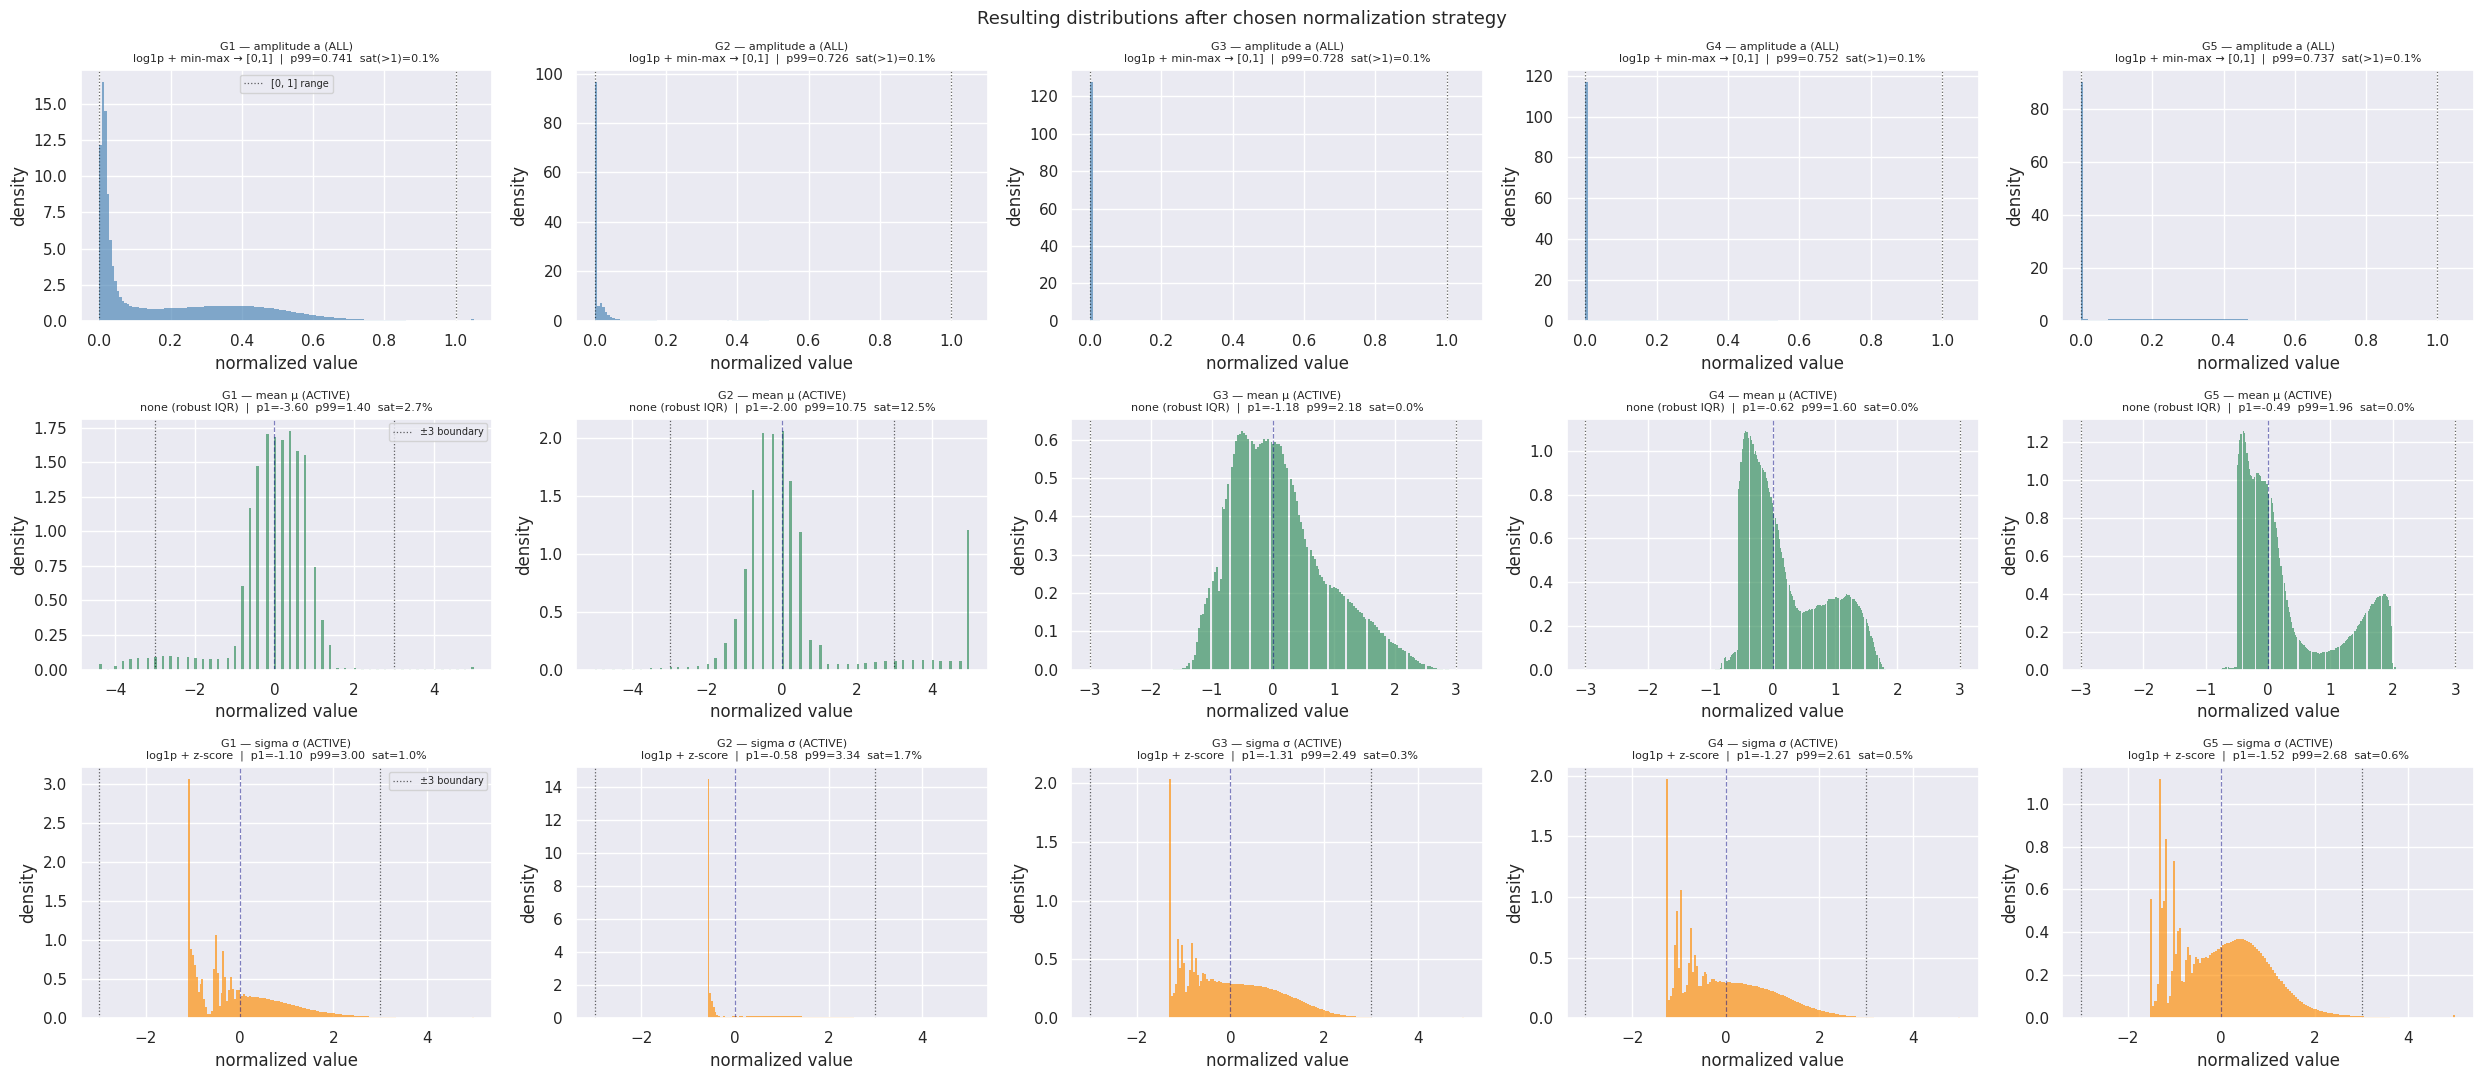

In [10]:
# ── Visual check: apply chosen strategy and inspect the resulting distributions ──
fig, axes = plt.subplots(3, n_gaussians, figsize=(5 * n_gaussians, 11), squeeze=False)

param_rows = [
    ("amp",   "amplitude a",  "steelblue",  "ALL"),
    ("mu",    "mean μ",       "seagreen",   "ACTIVE"),
    ("sigma", "sigma σ",      "darkorange", "ACTIVE"),
]

for row, (pkey, plabel, pcol, pop) in enumerate(param_rows):
    is_minmax = (pkey == "amp")   # amplitude uses min-max → expected range [0, 1]

    for k in range(n_gaussians):
        ax = axes[row, k]
        d  = data[k]

        arr = d[pkey] if pop == "ALL" else d[pkey][d["active"]]

        s      = chosen_stats[{"amp": amp_idx, "mu": mu_idx, "sigma": sigma_idx}[pkey][k]]
        mn, sd = s["mean"], s["std"]

        # Apply transform
        if "log1p" in s["transform"]:
            arr_t = np.log1p(np.maximum(arr, 0))
        else:
            arr_t = arr.copy()

        normed = (arr_t - mn) / sd

        if is_minmax:
            # min-max: clip to [0, 1.05] for display; saturation = values > 1
            sat    = 100.0 * (normed > 1.0).mean()
            clipped = np.clip(normed, 0, 1.05)
            ax.hist(clipped, bins=150, density=True, color=pcol, alpha=0.65, edgecolor="none")
            ax.axvline(0, color="black", lw=0.9, linestyle=":", alpha=0.6, label="[0, 1] range")
            ax.axvline(1, color="black", lw=0.9, linestyle=":", alpha=0.6)
            p1, p99 = np.percentile(normed, [1, 99])
            ax.set_title(
                f"G{k+1} — {plabel} (ALL)\n"
                f"log1p + min-max → [0,1]  |  p99={p99:.3f}  sat(>1)={sat:.1f}%",
                fontsize=8
            )
        else:
            # z-score / robust IQR: clip to [-5, 5]; saturation = outside ±3
            sat    = 100.0 * ((normed < -3) | (normed > 3)).mean()
            clipped = np.clip(normed, -5, 5)
            ax.hist(clipped, bins=150, density=True, color=pcol, alpha=0.65, edgecolor="none")
            ax.axvline(-3, color="black", lw=0.9, linestyle=":", alpha=0.6, label="±3 boundary")
            ax.axvline( 3, color="black", lw=0.9, linestyle=":", alpha=0.6)
            ax.axvline( 0, color="navy",  lw=0.9, linestyle="--", alpha=0.5)
            p1, p99 = np.percentile(normed, [1, 99])
            ax.set_title(
                f"G{k+1} — {plabel} (ACTIVE)\n"
                f"{s['transform']}  |  p1={p1:.2f}  p99={p99:.2f}  sat={sat:.1f}%",
                fontsize=8
            )

        ax.set_xlabel("normalized value")
        ax.set_ylabel("density")
        if k == 0:
            ax.legend(fontsize=7)

fig.suptitle("Resulting distributions after chosen normalization strategy", fontsize=13)
fig.tight_layout()
plt.show()


## 13 · Diagnostic — Amplitude spike & Sigma quantization

Two remaining issues from the visual check above:
1. **Amplitude**: the huge spike at 0 is all background pixels collapsing to `log1p(0)=0` under min-max. We verify the active-pixel tail looks healthy in isolation.
2. **Sigma spikes**: the histogram shows narrow spikes at specific normalized values. These are likely **integer-valued** sigma entries in the dataset. We check the top sigma values by count, and whether raising the amplitude threshold to filter "barely-active" Gaussians removes the degenerate small-sigma pixels.

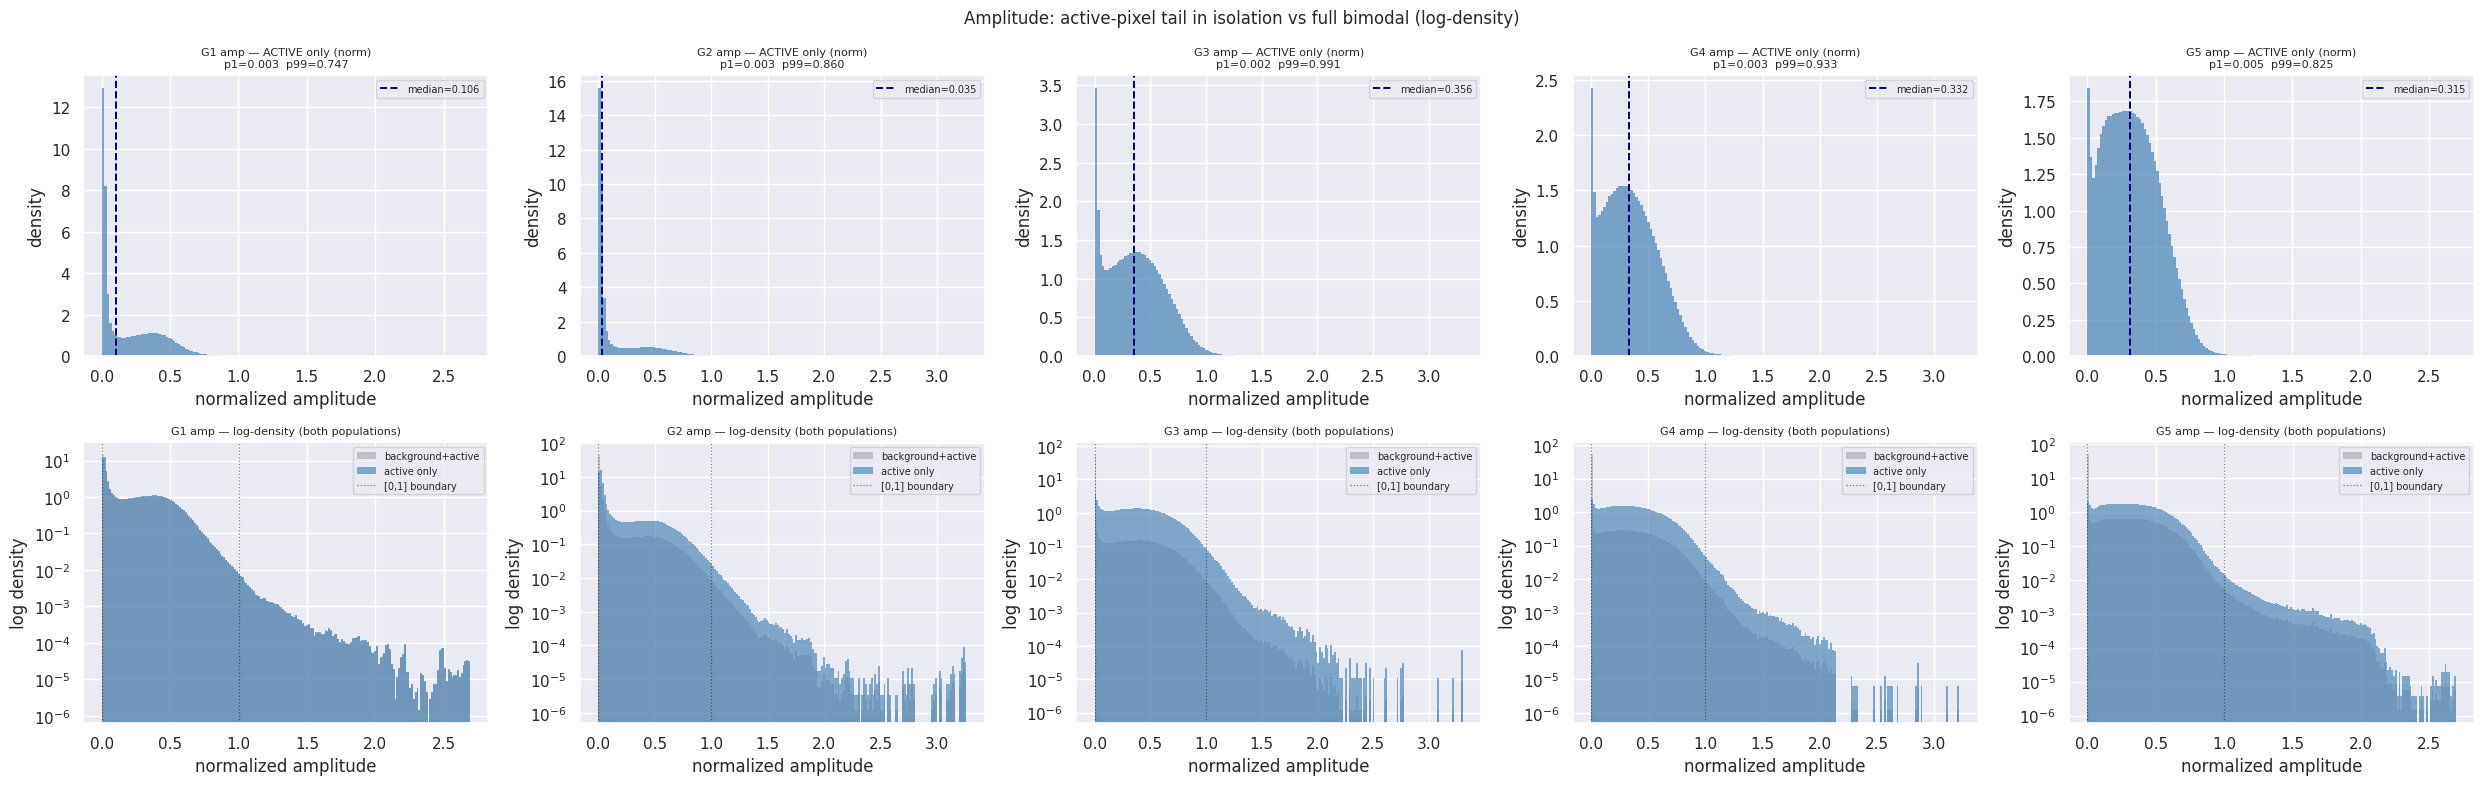

In [11]:
# ── 13a · Amplitude: separate background spike from active tail ───────────────
fig, axes = plt.subplots(2, n_gaussians, figsize=(5 * n_gaussians, 8), squeeze=False)

for k in range(n_gaussians):
    d      = data[k]
    s_amp  = chosen_stats[amp_idx[k]]
    mn, sd = s_amp["mean"], s_amp["std"]

    a_all    = d["amp"]
    active   = d["active"]
    a_log    = np.log1p(np.maximum(a_all, 0))
    a_normed = (a_log - mn) / sd

    # Top row: active pixels only — shows the "tail" in isolation
    ax0 = axes[0, k]
    act_normed = a_normed[active]
    ax0.hist(act_normed, bins=150, density=True, color="steelblue", alpha=0.7, edgecolor="none")
    ax0.axvline(np.median(act_normed), color="navy", lw=1.4, linestyle="--",
                label=f"median={np.median(act_normed):.3f}")
    p1, p99 = np.percentile(act_normed, [1, 99])
    ax0.set_title(f"G{k+1} amp — ACTIVE only (norm)\np1={p1:.3f}  p99={p99:.3f}", fontsize=8)
    ax0.set_xlabel("normalized amplitude")
    ax0.set_ylabel("density")
    ax0.legend(fontsize=7)

    # Bottom row: full population on log-density to see both background and active
    ax1 = axes[1, k]
    ax1.hist(a_normed,       bins=200, density=True, color="grey",      alpha=0.4,
             edgecolor="none", label="background+active")
    ax1.hist(act_normed,     bins=200, density=True, color="steelblue", alpha=0.65,
             edgecolor="none", label="active only")
    ax1.set_yscale("log")
    ax1.axvline(0, color="black", lw=0.9, linestyle=":", alpha=0.5)
    ax1.axvline(1, color="black", lw=0.9, linestyle=":", alpha=0.5, label="[0,1] boundary")
    ax1.set_title(f"G{k+1} amp — log-density (both populations)", fontsize=8)
    ax1.set_xlabel("normalized amplitude")
    ax1.set_ylabel("log density")
    ax1.legend(fontsize=7)

fig.suptitle("Amplitude: active-pixel tail in isolation vs full bimodal (log-density)", fontsize=12)
fig.tight_layout()
plt.show()


In [12]:
# ── 13b · Sigma: check for quantization (integer-valued entries) ──────────────
print("Top-20 most frequent RAW sigma values per Gaussian component (active pixels)\n")
print(f"{'G':>3}  {'sigma_value':>12}  {'count':>10}  {'% of active':>12}  {'log1p':>8}  {'z-normed':>10}")
print("-" * 60)

for k in range(n_gaussians):
    d     = data[k]
    sig   = d["sigma"][d["active"]]
    s_sig = chosen_stats[sigma_idx[k]]

    # Round to 4 decimal places to detect near-integer values
    vals, cnts = np.unique(np.round(sig, 4), return_counts=True)
    order = np.argsort(-cnts)[:20]

    for v, c in zip(vals[order], cnts[order]):
        log_v   = float(np.log1p(max(v, 0)))
        z_v     = (log_v - s_sig["mean"]) / s_sig["std"]
        pct     = 100.0 * c / len(sig)
        marker  = "  ← integer!" if abs(v - round(v)) < 0.01 else ""
        print(f"G{k+1}  {v:>12.4f}  {c:>10,}  {pct:>11.2f}%  {log_v:>8.4f}  {z_v:>10.4f}{marker}")
    print()


Top-20 most frequent RAW sigma values per Gaussian component (active pixels)

  G   sigma_value       count   % of active     log1p    z-normed
------------------------------------------------------------
G1        0.6711   4,496,910         9.00%    0.5135     -1.0992
G1        1.1261       6,782         0.01%    0.7543     -0.5058
G1        0.6975       6,691         0.01%    0.5292     -1.0606
G1        0.7051       6,685         0.01%    0.5336     -1.0496
G1        0.6988       6,682         0.01%    0.5299     -1.0587
G1        1.1214       6,679         0.01%    0.7521     -0.5113
G1        0.7032       6,640         0.01%    0.5325     -1.0523
G1        0.7049       6,625         0.01%    0.5335     -1.0499
G1        1.1303       6,612         0.01%    0.7563     -0.5009
G1        1.1266       6,609         0.01%    0.7545     -0.5052
G1        0.7056       6,606         0.01%    0.5339     -1.0489
G1        0.7009       6,605         0.01%    0.5312     -1.0557
G1        1.125

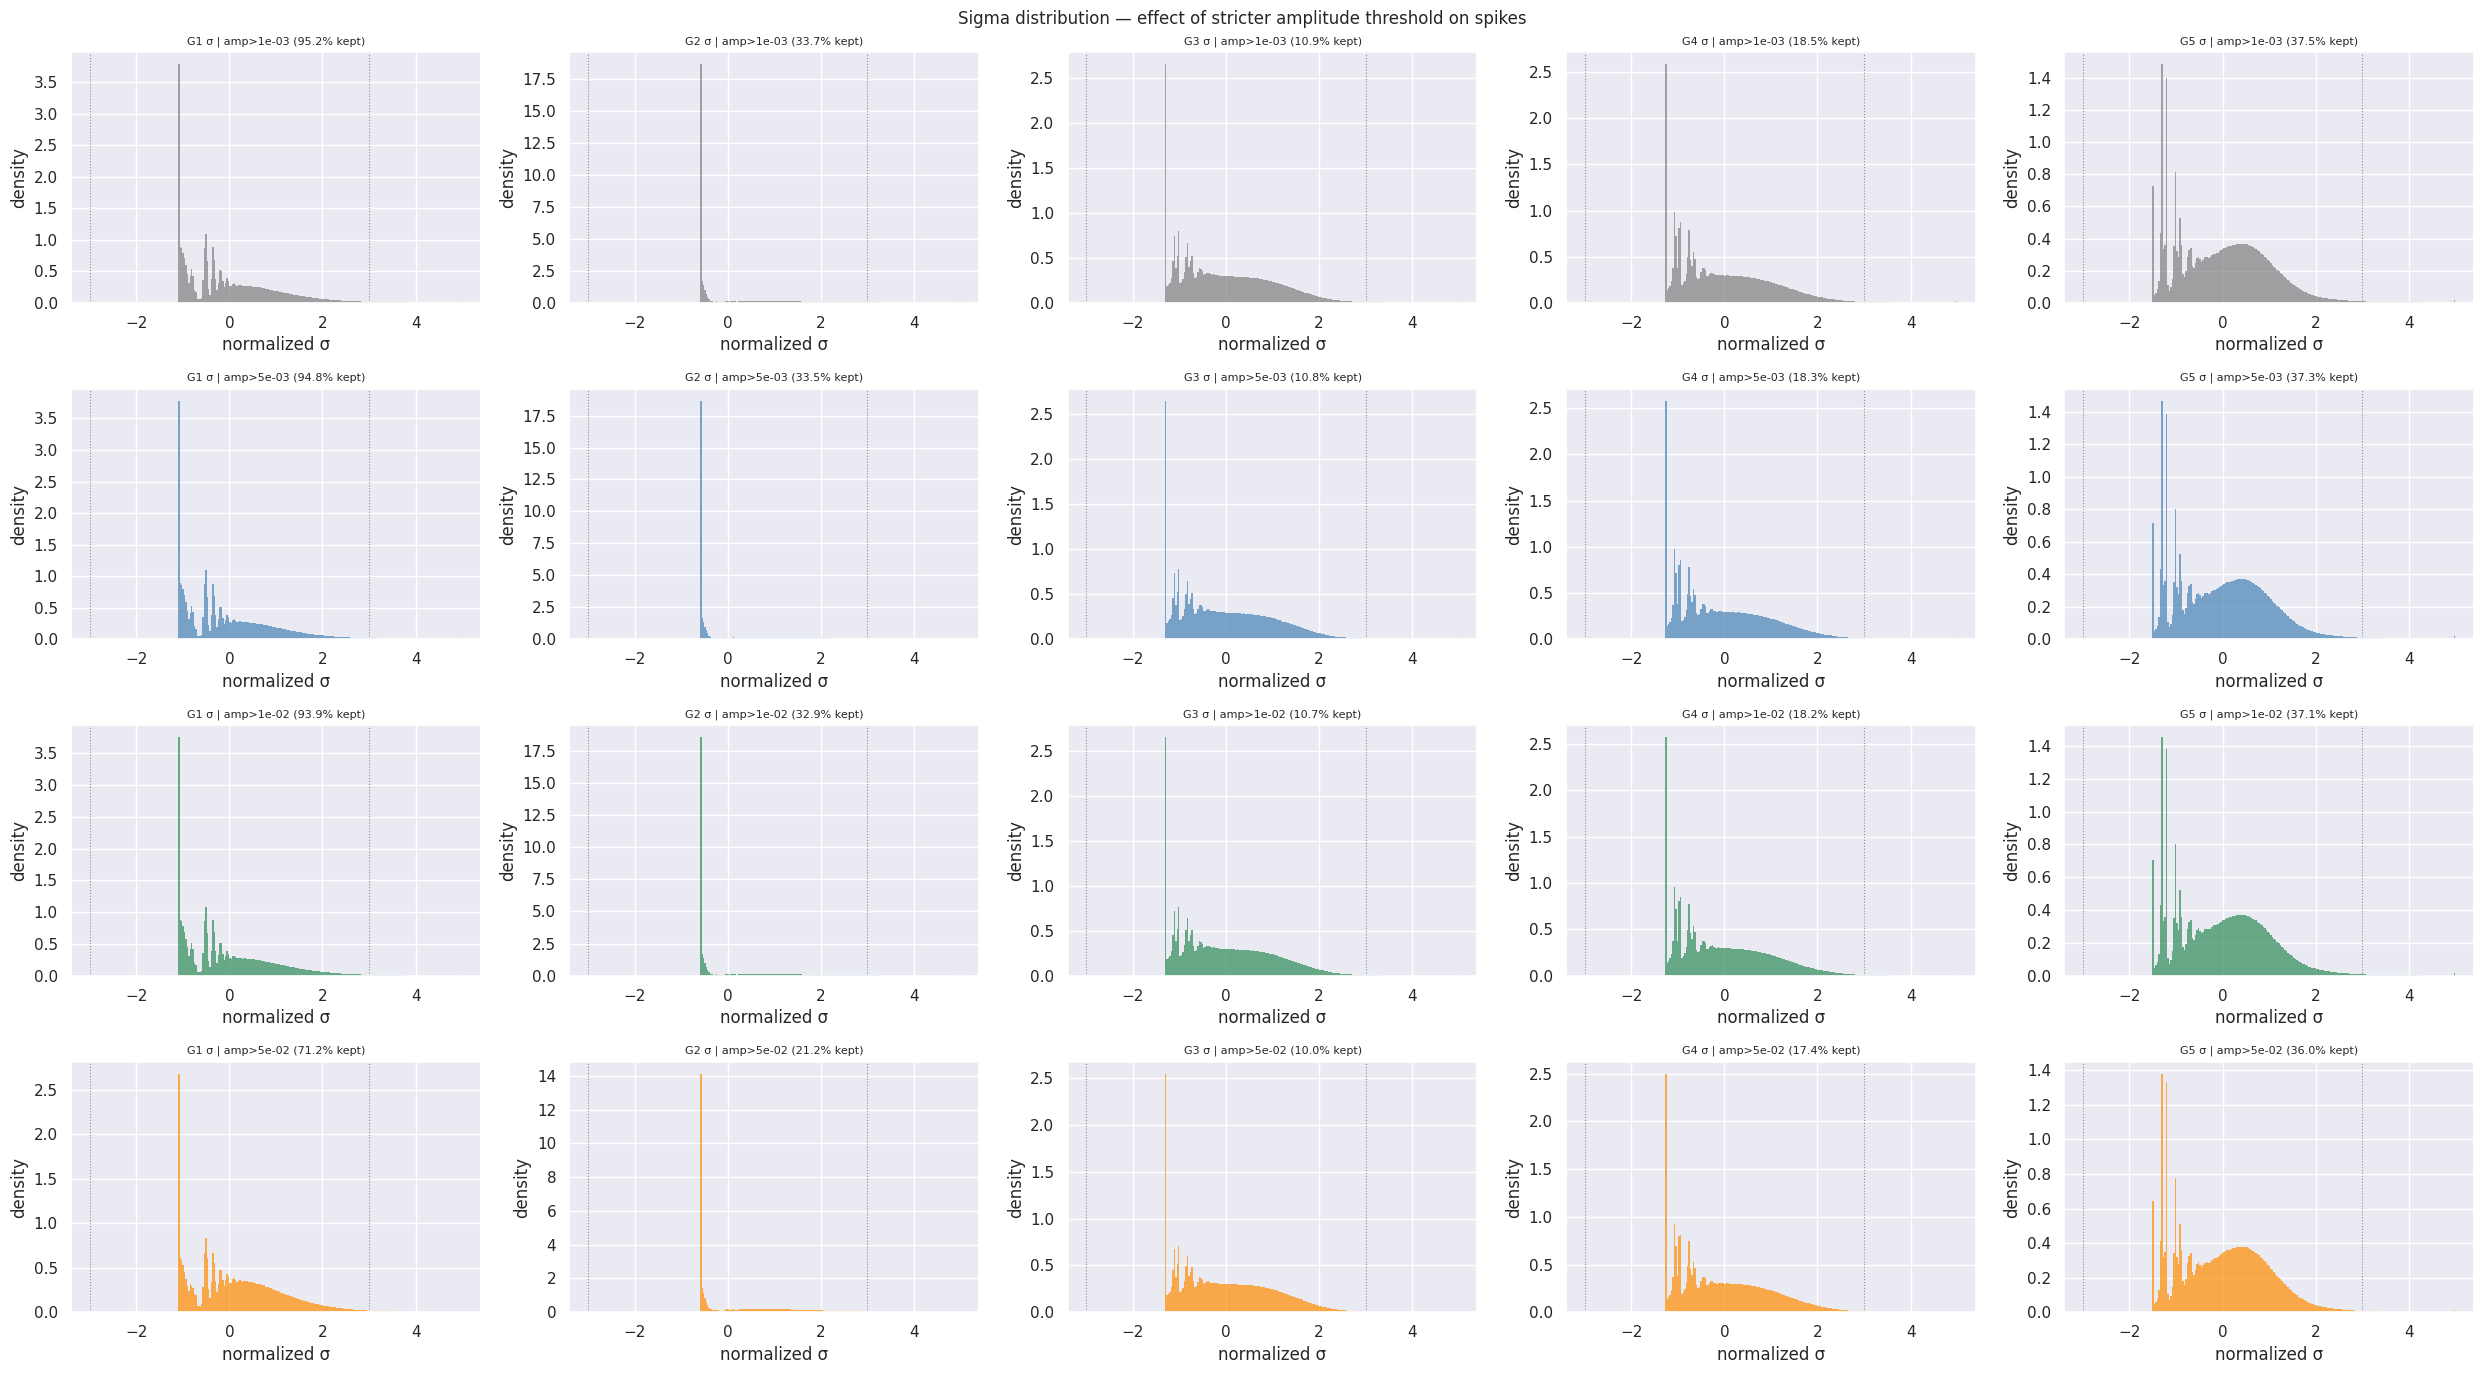

In [13]:
# ── 13c · Sigma: effect of stricter amplitude threshold on spikes ─────────────
# If "borderline active" pixels (low amplitude but > 1e-3) carry degenerate
# integer/placeholder sigma values, a stricter threshold should remove the spikes.

amp_thresholds_test = [1e-3, 5e-3, 1e-2, 5e-2]
thr_colors = ["grey", "steelblue", "seagreen", "darkorange"]

fig, axes = plt.subplots(len(amp_thresholds_test), n_gaussians,
                         figsize=(5 * n_gaussians, 3.5 * len(amp_thresholds_test)),
                         squeeze=False)

for row, thr in enumerate(amp_thresholds_test):
    for k in range(n_gaussians):
        ax    = axes[row, k]
        d     = data[k]
        s_sig = chosen_stats[sigma_idx[k]]

        mask  = d["amp"] > thr
        sig   = d["sigma"][mask]
        sig   = sig[np.isfinite(sig)]
        sig_log = np.log1p(np.maximum(sig, 0))
        normed  = (sig_log - s_sig["mean"]) / s_sig["std"]
        normed_c = np.clip(normed, -5, 5)

        n_kept = mask.sum()
        n_all  = len(d["amp"])

        ax.hist(normed_c, bins=200, density=True, color=thr_colors[row],
                alpha=0.7, edgecolor="none")
        ax.axvline(-3, color="black", lw=0.8, linestyle=":", alpha=0.4)
        ax.axvline( 3, color="black", lw=0.8, linestyle=":", alpha=0.4)
        ax.set_title(
            f"G{k+1} σ | amp>{thr:.0e} ({100*n_kept/n_all:.1f}% kept)",
            fontsize=8
        )
        ax.set_xlabel("normalized σ")
        ax.set_ylabel("density")

fig.suptitle("Sigma distribution — effect of stricter amplitude threshold on spikes", fontsize=12)
fig.tight_layout()
plt.show()


### What needs to change in `StatsComputer` / `Normalizer`

The current `StatsComputer` runs a standard **z-score on all pixels** for every output channel (no transform, no masking).  
Based on the analysis above, the following changes are needed:

| Parameter | Population for stats | Transform | Normalization | Output range |
|---|---|---|---|---|
| **amplitude `a`** | **ALL pixels** | `log1p(a)` | **min-max**: `(log1p(a) − 0) / log1p(p99.9_a)` | `[0, 1]` |
| **mean `μ`** | **Active pixels only** | none | **robust IQR**: `(μ − median) / IQR` | centred at 0 |
| **sigma `σ`** | **Active pixels only** | `log1p(σ)` | **z-score** on log | centred at 0 |

**Why min-max for amplitude?**  
`log1p + z-score` over ALL pixels fails because the distribution is bimodal (huge spike at `log1p(0)=0` for background, separate hump for active pixels). The z-score center falls in the gap between modes. Min-max avoids this cleanly: background always maps to `0`, the brightest scatterer maps to `1`, and the formula is still `(x − mean) / std` with `mean = 0`, `std = log1p(p99.9)`.

| What | Current behaviour | Required behaviour |
|---|---|---|
| **Amplitude stats** | z-score on all pixels, raw values | min-max on `log1p(a)`, all pixels; `mean=0`, `std=log1p(p99.9)` |
| **μ stats** | z-score on all pixels, raw values | robust IQR (`median`, `IQR`) on **active pixels only** |
| **σ stats** | z-score on all pixels, raw values | z-score on **log1p(σ)**, **active pixels only** |
| **Normalizer forward** | `(x − mean) / std` | apply `log1p` pre-transform for `a` and `σ` before the linear rescale |
| **Normalizer inverse** | `x * std + mean` | apply `expm1` post-transform after the inverse rescale for `a` and `σ` |

The `chosen_stats` dict contains the exact `mean` / `std` to store per channel.


---
## 14 · Re-centering: What we actually found

### The sigma spikes are **data artifacts**, not a normalization problem

The quantization analysis (cell 29) reveals everything:

| Spike | Value | Fraction of active pixels | What it is |
|---|---|---|---|
| **Main spike** | `σ ≈ 0.6711` | 2 – 47 % depending on component | **Placeholder / default value** written by the dataset generator for pixels that technically have `amp > 1e-3` but do not carry a real scatterer |
| **Right tail spike** | `σ = 50.0` | ~0.02 – 0.04 % | Sentinel for very flat / unconstrained Gaussians |

### ✅ Decision: Option A — Accept the placeholder pixels as-is

The amplitude diagnostic (cell below) confirms that pixels with `σ ≈ 0.6711` are **not clustered near the `1e-3` threshold** — they span a wide amplitude range and cannot be cleanly separated by any amplitude cutoff. Raising `AMP_THRESHOLD` would discard large numbers of genuinely active pixels while still leaving many placeholders behind.

**Consequence:** the spike in the σ distribution is real data. The network will see `σ ≈ 0.6711` as a common output for low-confidence pixels. The amplitude-based **loss mask** already suppresses the gradient for pixels the model should ignore, so training is not harmed.

### Final normalization status

| Parameter | Strategy | Status |
|---|---|---|
| **amplitude `a`** | `log1p` + min-max, ALL pixels | ✅ looks good |
| **mean `μ`** | robust IQR, active pixels | ✅ looks good |
| **sigma `σ`** | `log1p` + z-score, active pixels | ✅ spike is a data artifact — accepted; normalization itself is correct |


/tmp/ipykernel_3826978/3088882394.py:53: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


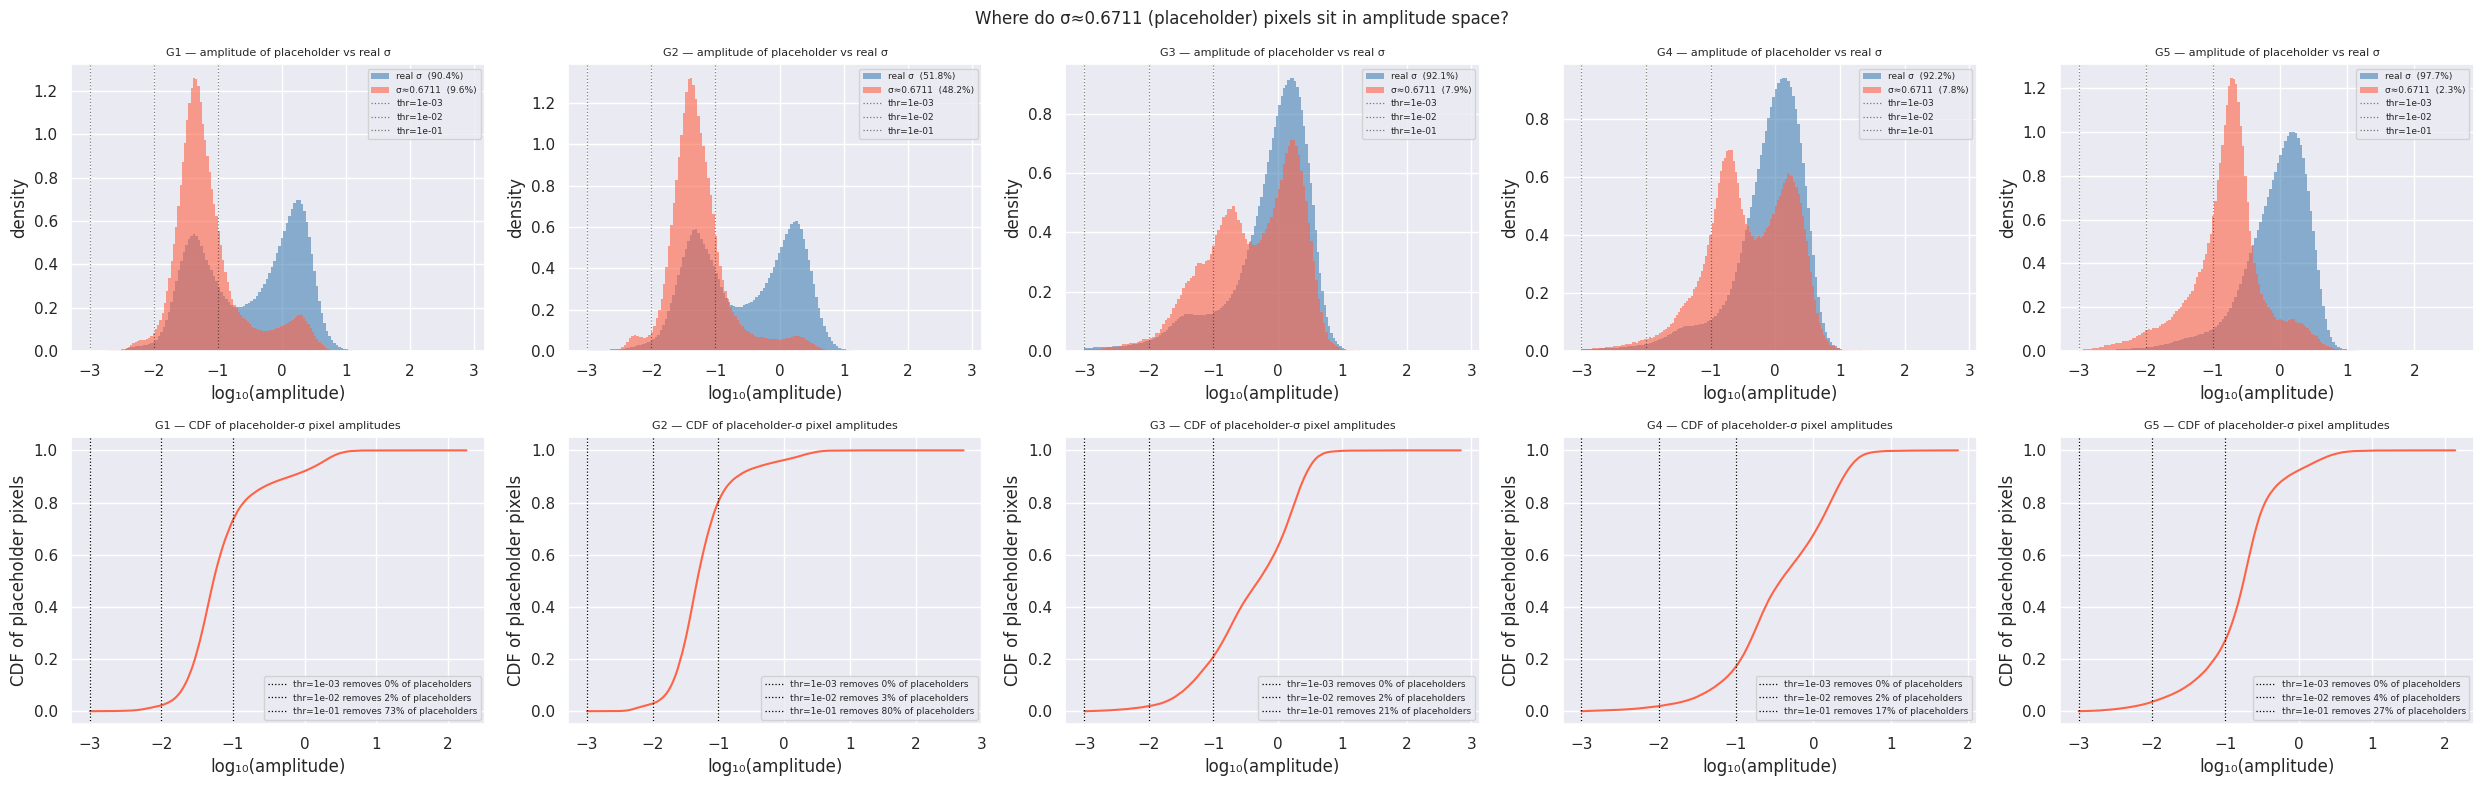

In [14]:
# ── 14 · Amplitude distribution of placeholder-sigma pixels ──────────────────
# Do pixels with sigma ≈ 0.6711 cluster at low amplitude?
# If yes → a higher amp threshold can cleanly remove them.

PLACEHOLDER_SIGMA = 0.6711
PLACEHOLDER_TOL   = 0.005   # ±0.005 around the placeholder value

fig, axes = plt.subplots(2, n_gaussians, figsize=(5 * n_gaussians, 8), squeeze=False)

for k in range(n_gaussians):
    d      = data[k]
    active = d["active"]
    amp    = d["amp"][active]
    sig    = d["sigma"][active]

    is_placeholder = np.abs(sig - PLACEHOLDER_SIGMA) < PLACEHOLDER_TOL
    amp_placeholder = amp[is_placeholder]
    amp_real        = amp[~is_placeholder]

    pct_ph = 100.0 * is_placeholder.mean()

    # Top: log-scale amplitude histogram, placeholder vs real
    ax0 = axes[0, k]
    log_amp_ph   = np.log10(amp_placeholder + 1e-10)
    log_amp_real = np.log10(amp_real        + 1e-10)
    ax0.hist(log_amp_real,   bins=150, density=True, color="steelblue",
             alpha=0.6, edgecolor="none", label=f"real σ  ({100-pct_ph:.1f}%)")
    ax0.hist(log_amp_ph,     bins=150, density=True, color="tomato",
             alpha=0.6, edgecolor="none", label=f"σ≈{PLACEHOLDER_SIGMA}  ({pct_ph:.1f}%)")
    for thr in [1e-3, 1e-2, 0.1]:
        ax0.axvline(np.log10(thr), color="black", lw=0.9, linestyle=":", alpha=0.5,
                    label=f"thr={thr:.0e}")
    ax0.set_title(f"G{k+1} — amplitude of placeholder vs real σ", fontsize=8)
    ax0.set_xlabel("log₁₀(amplitude)")
    ax0.set_ylabel("density")
    ax0.legend(fontsize=6.5)

    # Bottom: CDF of amplitude for placeholder pixels → where to cut?
    ax1 = axes[1, k]
    s_ph  = np.sort(amp_placeholder)
    cdf_ph = np.arange(1, len(s_ph)+1) / len(s_ph)
    ax1.plot(np.log10(s_ph + 1e-10), cdf_ph, color="tomato", lw=1.5)
    for thr in [1e-3, 1e-2, 0.1]:
        pct_removed = 100.0 * (amp_placeholder < thr).mean()
        ax1.axvline(np.log10(thr), color="black", lw=0.9, linestyle=":",
                    label=f"thr={thr:.0e} removes {pct_removed:.0f}% of placeholders")
    ax1.set_title(f"G{k+1} — CDF of placeholder-σ pixel amplitudes", fontsize=8)
    ax1.set_xlabel("log₁₀(amplitude)")
    ax1.set_ylabel("CDF of placeholder pixels")
    ax1.legend(fontsize=6.5)

fig.suptitle(f"Where do σ≈{PLACEHOLDER_SIGMA} (placeholder) pixels sit in amplitude space?", fontsize=12)
fig.tight_layout()
plt.show()


---
## 15 · Final Normalization — Before & After Distributions

### Confirmed strategy

| Parameter | Population | Transform | Normalization | Output range |
|---|---|---|---|---|
| **amplitude `a`** | ALL pixels | `log1p(a)` | min-max with `max = log1p(p99.9)` | `[0, 1]` |
| **mean `μ`** | Active pixels only | none | robust IQR: `(x − median) / IQR` | centred at 0 |
| **sigma `σ`** | Active pixels only | `log1p(σ)` | z-score on the log | centred at 0 |

The spike at `σ ≈ 0.6711` is a **dataset placeholder** that spans the full amplitude range — it cannot be removed by thresholding and is accepted as valid data. The amplitude loss mask suppresses its gradient contribution during training.

The plots below show:
1. **Per-Gaussian, per-parameter** — raw distribution (grey) vs normalised distribution (colour), one column per Gaussian component.
2. **All Gaussians pooled** — same before/after but with all components overlaid, confirming that the chosen strategy aligns the components.


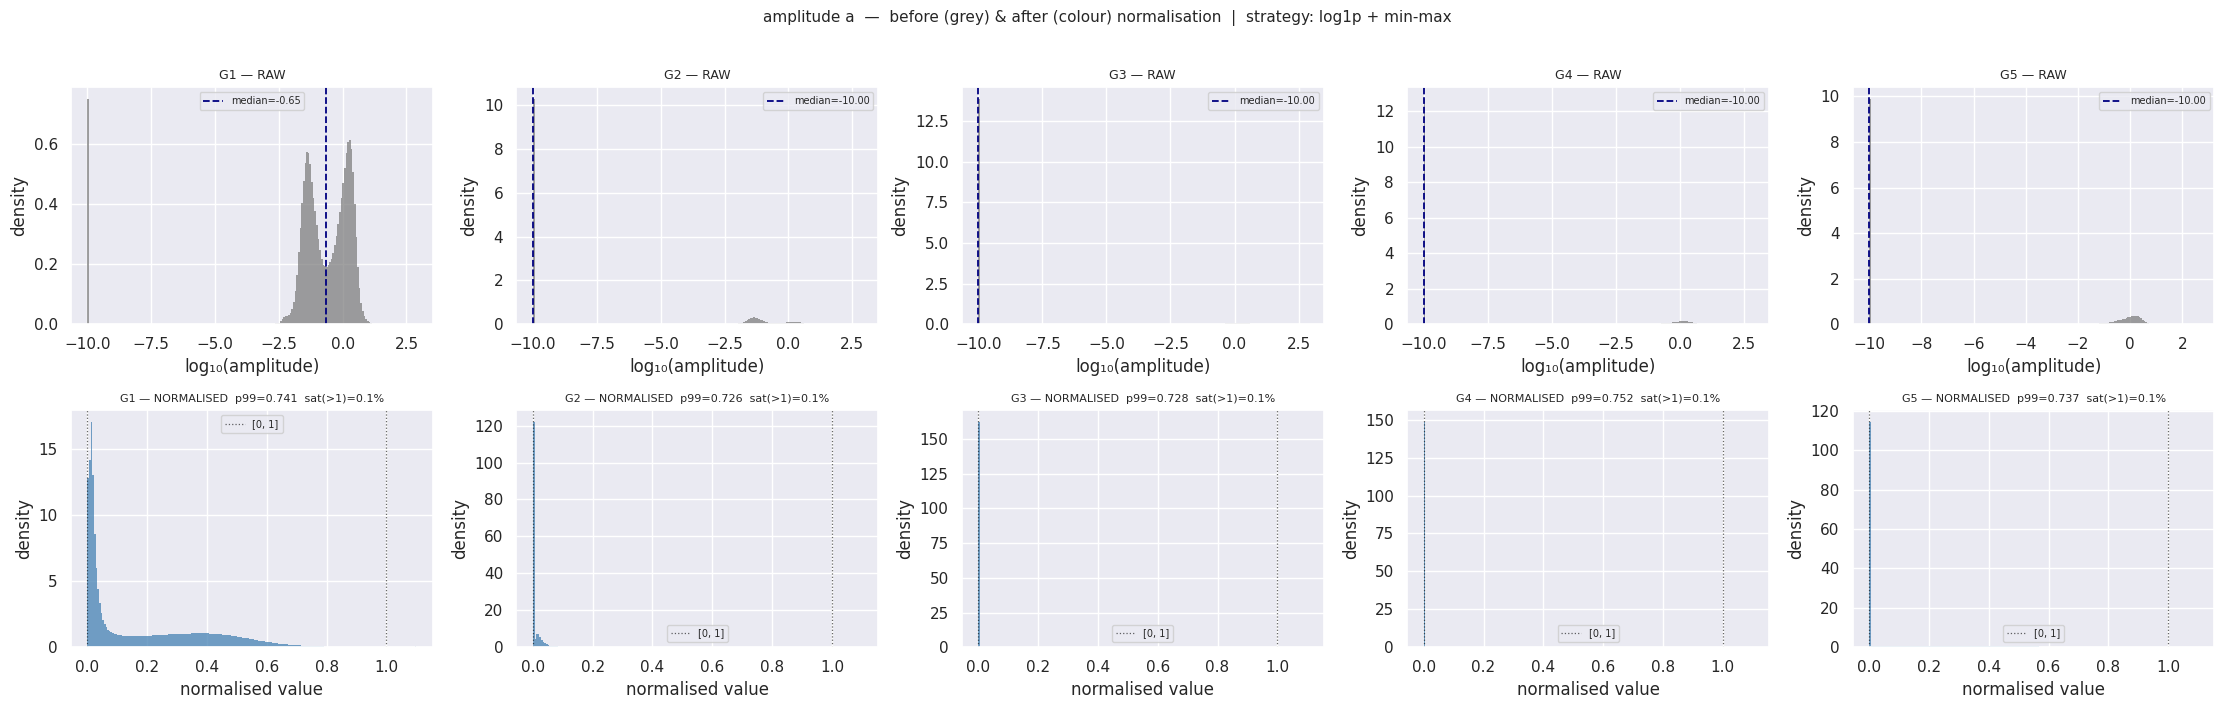

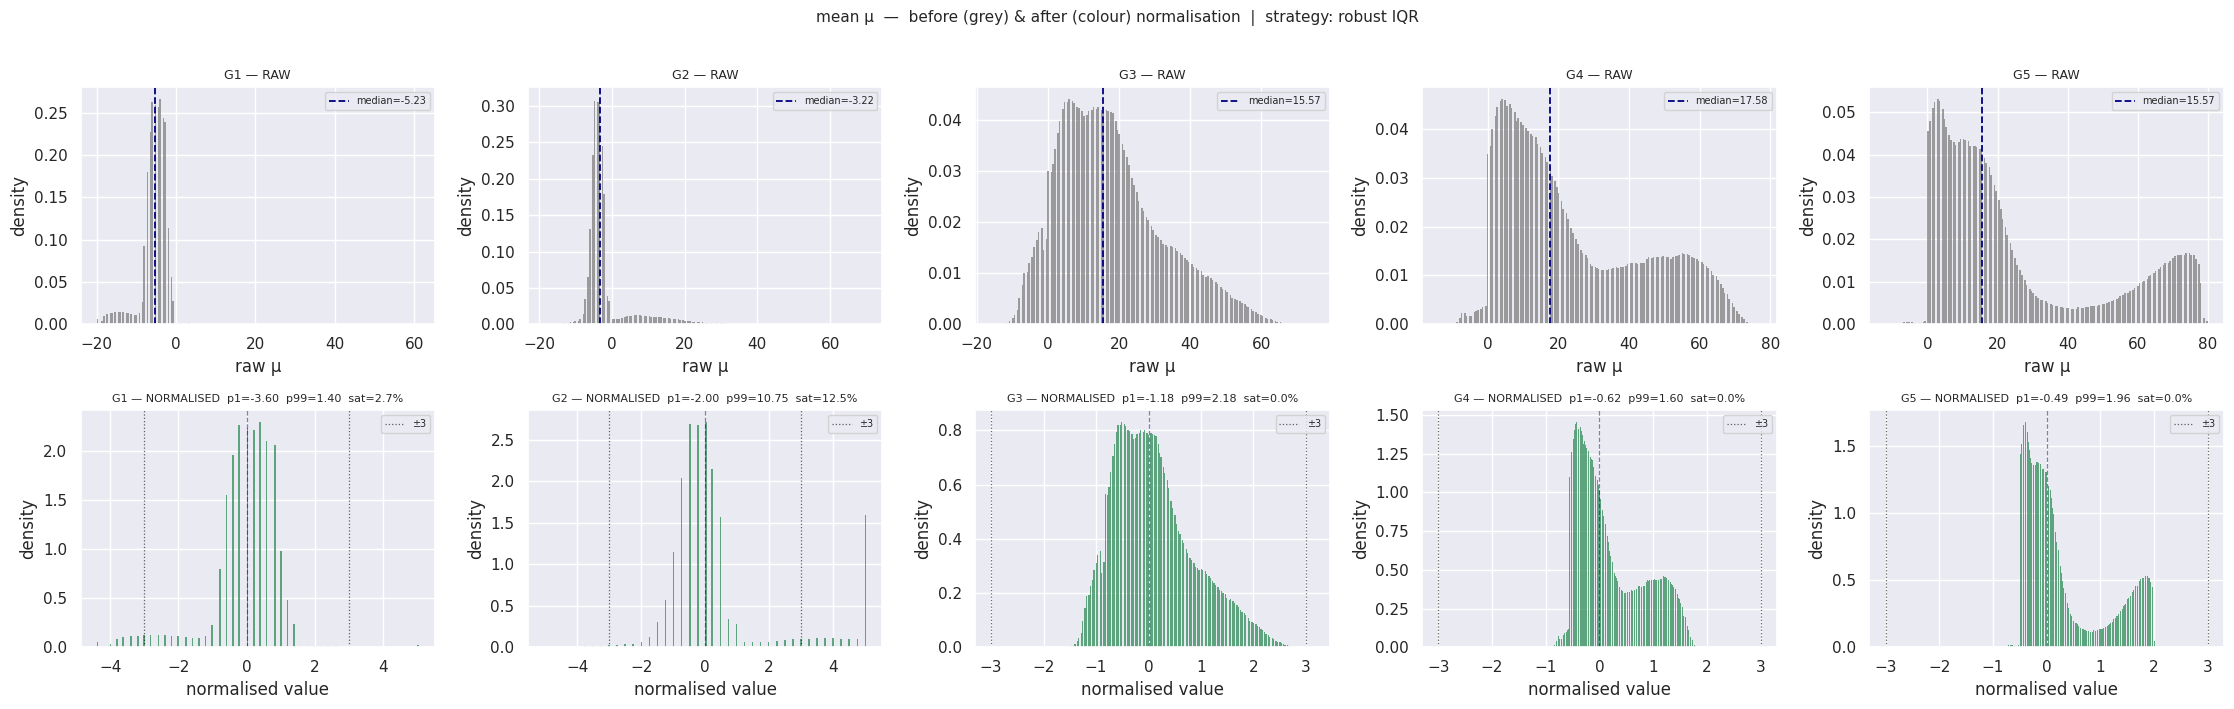

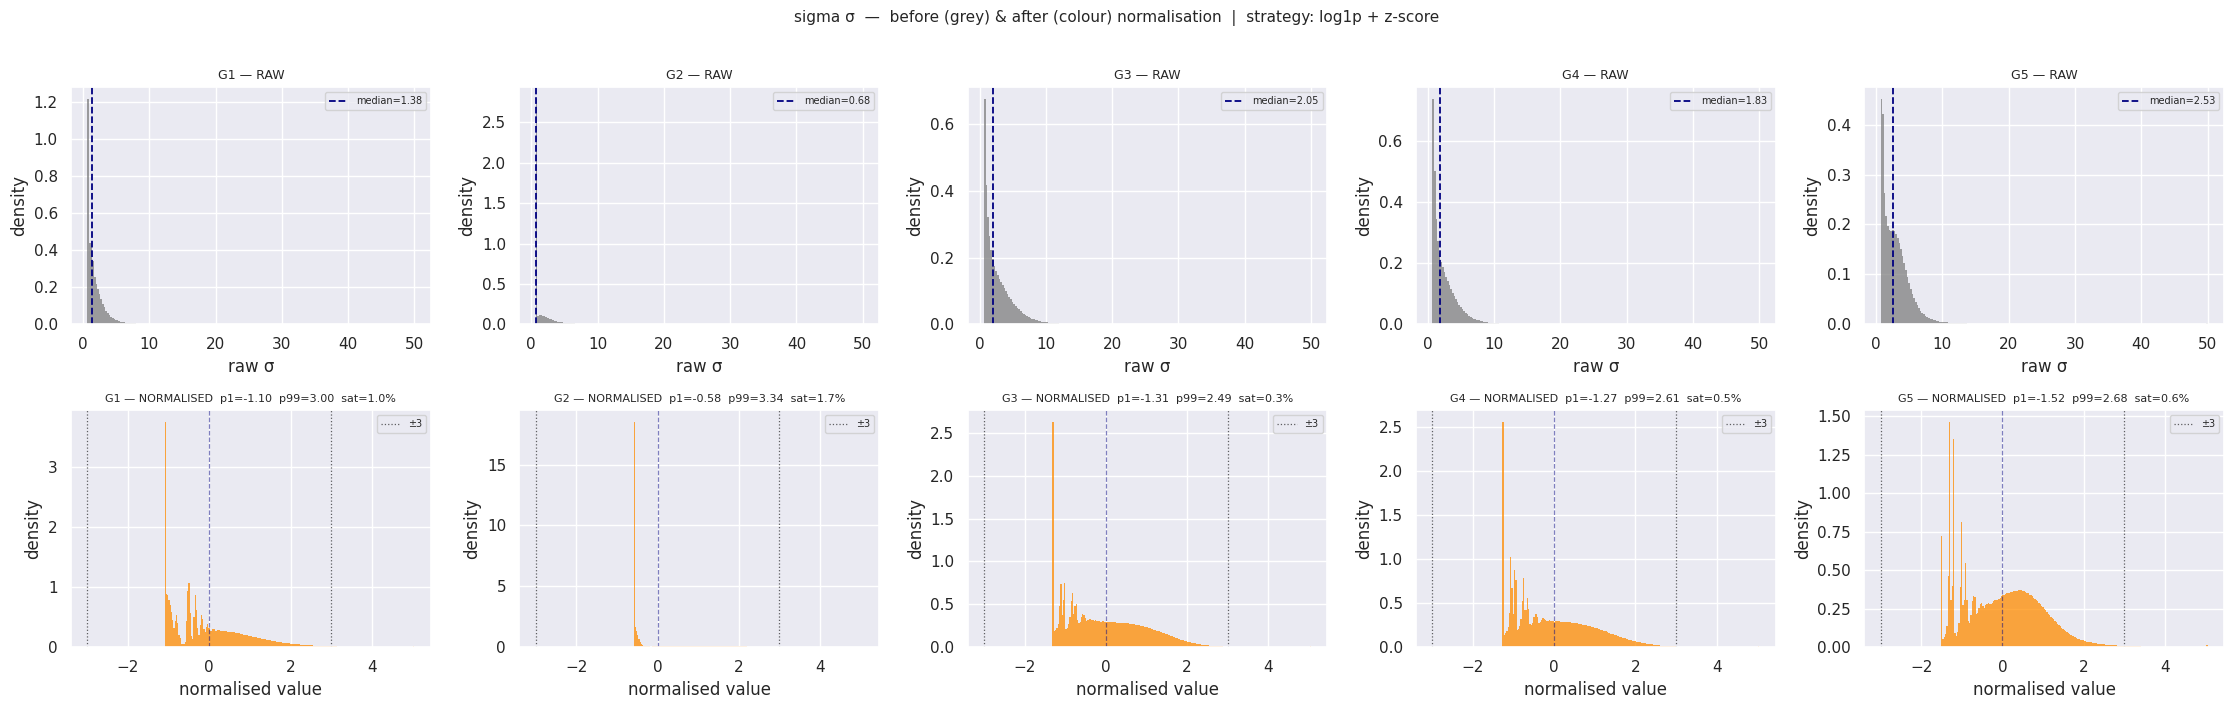

In [15]:
# ── 15a · Before & After — per Gaussian, per parameter ───────────────────────
import matplotlib.gridspec as gridspec

param_cfg = [
    # (pkey,   plabel,       color,        population,  transform_label,  clip_lo, clip_hi, x_raw_label)
    ("amp",   "amplitude a", "steelblue",  "ALL",       "log1p + min-max", 0,    1.05,  "raw amplitude"),
    ("mu",    "mean μ",      "seagreen",   "ACTIVE",    "robust IQR",     -5,    5,     "raw μ"),
    ("sigma", "sigma σ",     "darkorange", "ACTIVE",    "log1p + z-score",-5,    5,     "raw σ"),
]

for pkey, plabel, pcol, pop, tlabel, clip_lo, clip_hi, raw_xlabel in param_cfg:
    is_amp = (pkey == "amp")
    fig, axes = plt.subplots(2, n_gaussians, figsize=(4.5 * n_gaussians, 7), squeeze=False)
    fig.suptitle(f"{plabel}  —  before (grey) & after (colour) normalisation  |  strategy: {tlabel}",
                 fontsize=11, y=1.01)

    for k in range(n_gaussians):
        d   = data[k]
        arr = d[pkey] if pop == "ALL" else d[pkey][d["active"]]
        s   = chosen_stats[{"amp": amp_idx, "mu": mu_idx, "sigma": sigma_idx}[pkey][k]]
        mn, sd = s["mean"], s["std"]

        # ── Raw ──────────────────────────────────────────────────────────
        ax_raw = axes[0, k]
        arr_plot = np.log10(arr + 1e-10) if is_amp else arr
        raw_lbl  = "log₁₀(amplitude)" if is_amp else raw_xlabel
        ax_raw.hist(arr_plot, bins=200, density=True,
                    color="grey", alpha=0.75, edgecolor="none")
        ax_raw.set_title(f"G{k+1} — RAW", fontsize=9)
        ax_raw.set_xlabel(raw_lbl)
        ax_raw.set_ylabel("density")

        # mark mean / median
        center = float(np.median(arr_plot))
        ax_raw.axvline(center, color="navy", lw=1.3, linestyle="--",
                       label=f"median={center:.2f}")
        ax_raw.legend(fontsize=7)

        # ── Normalised ───────────────────────────────────────────────────
        ax_norm = axes[1, k]
        if "log1p" in s["transform"]:
            arr_t = np.log1p(np.maximum(arr, 0))
        else:
            arr_t = arr.copy()
        normed  = (arr_t - mn) / sd
        clipped = np.clip(normed, clip_lo - 0.05, clip_hi + 0.05)

        ax_norm.hist(clipped, bins=200, density=True,
                     color=pcol, alpha=0.75, edgecolor="none")

        # reference lines
        if is_amp:
            ax_norm.axvline(0, color="black", lw=0.9, linestyle=":", alpha=0.6, label="[0, 1]")
            ax_norm.axvline(1, color="black", lw=0.9, linestyle=":", alpha=0.6)
            p1, p99 = np.percentile(normed, [1, 99])
            sat = 100.0 * (normed > 1.0).mean()
            ax_norm.set_title(f"G{k+1} — NORMALISED  p99={p99:.3f}  sat(>1)={sat:.1f}%", fontsize=8)
        else:
            ax_norm.axvline(-3, color="black", lw=0.9, linestyle=":", alpha=0.6, label="±3")
            ax_norm.axvline( 3, color="black", lw=0.9, linestyle=":", alpha=0.6)
            ax_norm.axvline( 0, color="navy",  lw=0.9, linestyle="--", alpha=0.5)
            p1, p99 = np.percentile(normed, [1, 99])
            sat = 100.0 * ((normed < -3) | (normed > 3)).mean()
            ax_norm.set_title(f"G{k+1} — NORMALISED  p1={p1:.2f}  p99={p99:.2f}  sat={sat:.1f}%", fontsize=8)

        ax_norm.set_xlabel("normalised value")
        ax_norm.set_ylabel("density")
        ax_norm.legend(fontsize=7)

    fig.tight_layout()
    plt.show()


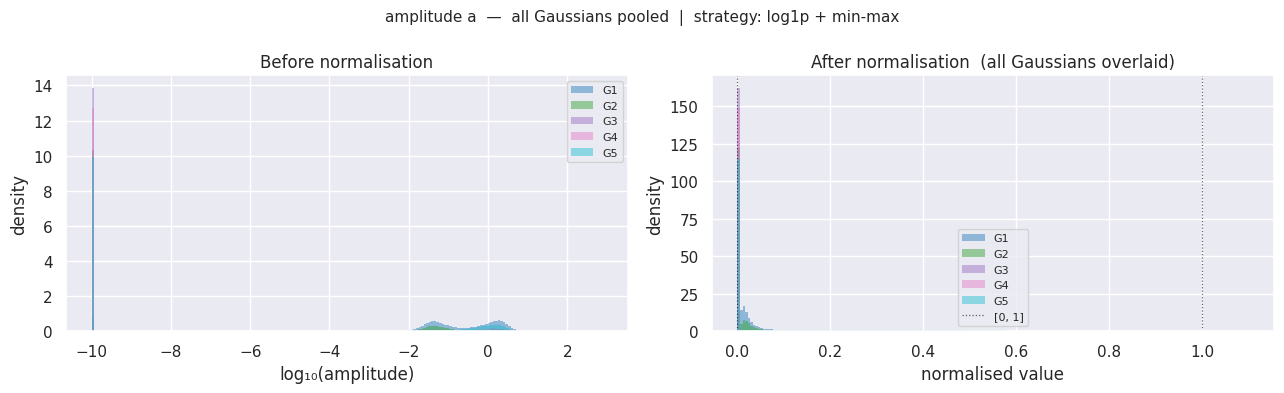

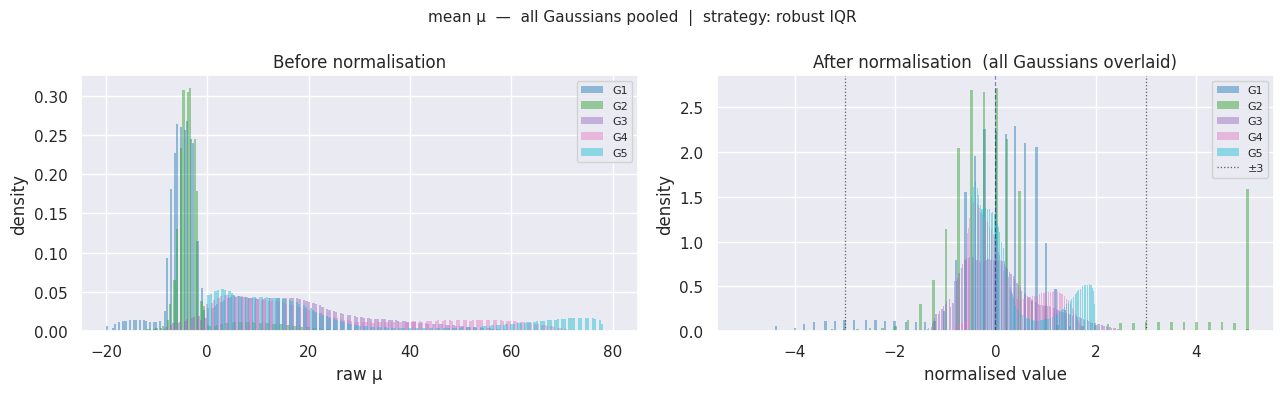

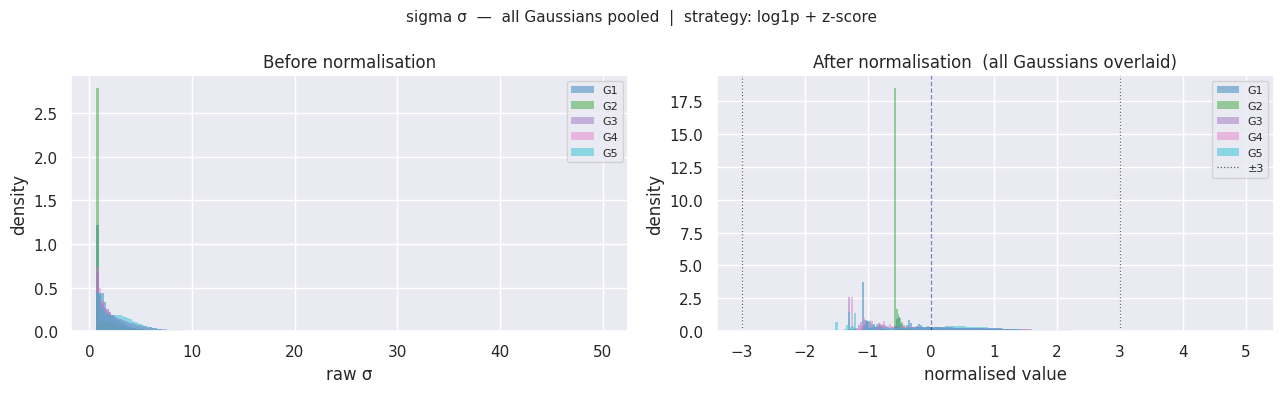

In [16]:
# ── 15b · Before & After — all Gaussians pooled, per parameter ───────────────
component_colors_15 = plt.cm.tab10(np.linspace(0, 0.9, n_gaussians))

for pkey, plabel, pcol, pop, tlabel, clip_lo, clip_hi, raw_xlabel in param_cfg:
    is_amp = (pkey == "amp")
    fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"{plabel}  —  all Gaussians pooled  |  strategy: {tlabel}", fontsize=11)

    for k in range(n_gaussians):
        col = component_colors_15[k]
        d   = data[k]
        arr = d[pkey] if pop == "ALL" else d[pkey][d["active"]]
        s   = chosen_stats[{"amp": amp_idx, "mu": mu_idx, "sigma": sigma_idx}[pkey][k]]
        mn, sd = s["mean"], s["std"]

        # ── Raw ──────────────────────────────────────────────────────────
        arr_plot = np.log10(arr + 1e-10) if is_amp else arr
        ax_raw.hist(arr_plot, bins=200, density=True,
                    color=col, alpha=0.45, edgecolor="none", label=f"G{k+1}")

        # ── Normalised ───────────────────────────────────────────────────
        if "log1p" in s["transform"]:
            arr_t = np.log1p(np.maximum(arr, 0))
        else:
            arr_t = arr.copy()
        normed  = (arr_t - mn) / sd
        clipped = np.clip(normed, clip_lo - 0.05, clip_hi + 0.05)
        ax_norm.hist(clipped, bins=200, density=True,
                     color=col, alpha=0.45, edgecolor="none", label=f"G{k+1}")

    # Reference lines
    raw_lbl = "log₁₀(amplitude)" if is_amp else raw_xlabel
    ax_raw.set_title("Before normalisation")
    ax_raw.set_xlabel(raw_lbl)
    ax_raw.set_ylabel("density")
    ax_raw.legend(fontsize=8)

    if is_amp:
        ax_norm.axvline(0, color="black", lw=0.9, linestyle=":", alpha=0.6, label="[0, 1]")
        ax_norm.axvline(1, color="black", lw=0.9, linestyle=":", alpha=0.6)
    else:
        ax_norm.axvline(-3, color="black", lw=0.9, linestyle=":", alpha=0.6, label="±3")
        ax_norm.axvline( 3, color="black", lw=0.9, linestyle=":", alpha=0.6)
        ax_norm.axvline( 0, color="navy",  lw=0.9, linestyle="--", alpha=0.5)
    ax_norm.set_title("After normalisation  (all Gaussians overlaid)")
    ax_norm.set_xlabel("normalised value")
    ax_norm.set_ylabel("density")
    ax_norm.legend(fontsize=8)

    fig.tight_layout()
    plt.show()


Single-pool group normalisation stats:
  amp   log1p+min-max   mean=0.00000  std=2.19227  (ALL pixels,    N=262,500,000)
  mu    robust IQR      mean=-3.22148  std=14.76510  (ACTIVE pixels, N=102,732,018)
  sigma log1p+z-score   mean=1.01318  std=0.47237  (ACTIVE pixels, N=102,732,018)


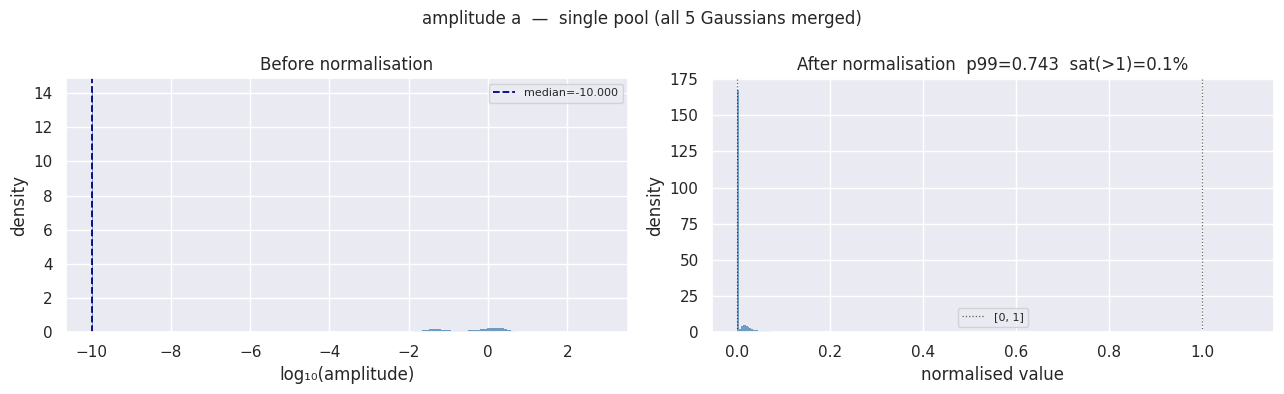

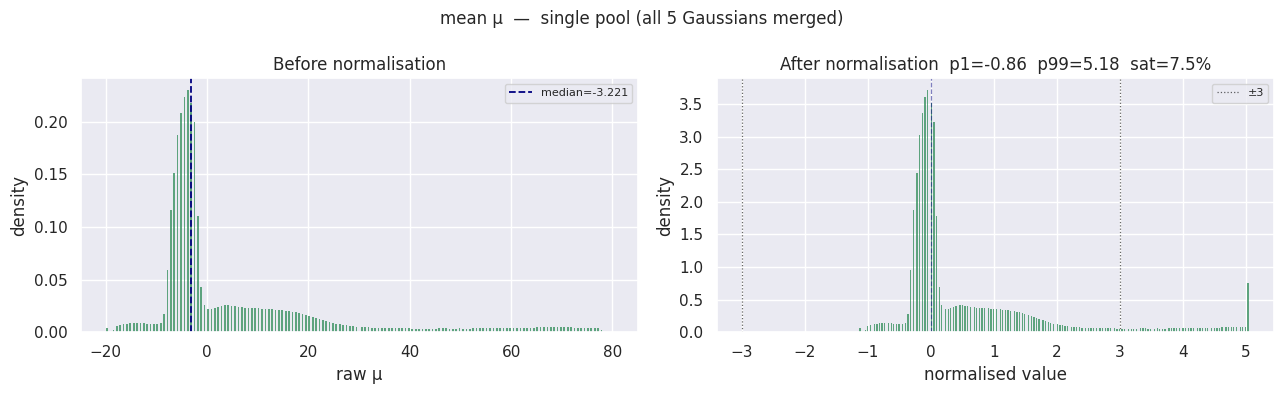

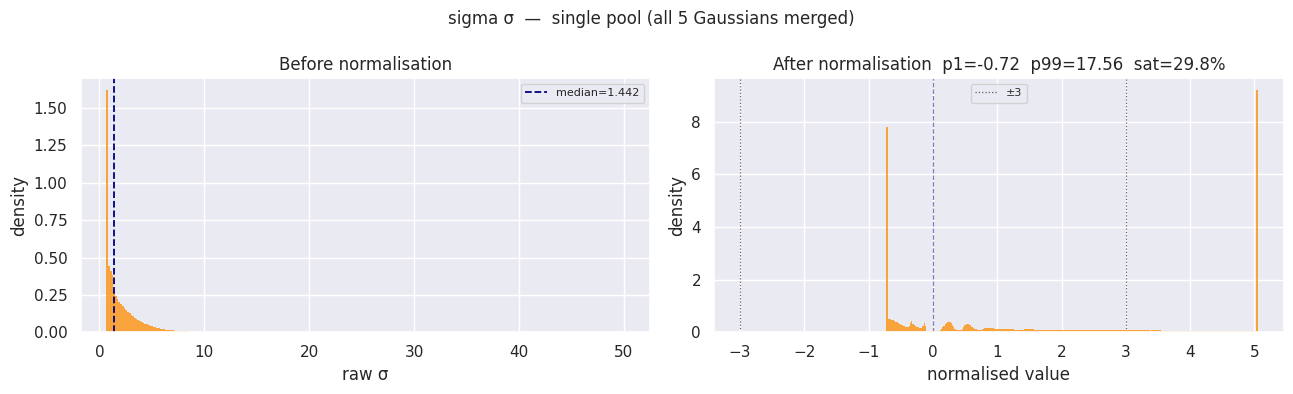

In [20]:
# ── 15c · Group normalisation — single pool per parameter type ───────────────
# Concatenate ALL Gaussians into one flat array per param, fit ONE normaliser,
# and show a single before/after histogram.

eps = 1e-8

# ── Build pools ───────────────────────────────────────────────────────────────
amp_pool  = np.concatenate([data[k]["amp"]                    for k in range(n_gaussians)])
mu_pool   = np.concatenate([data[k]["mu"][data[k]["active"]]  for k in range(n_gaussians)])
sig_pool  = np.concatenate([data[k]["sigma"][data[k]["active"]] for k in range(n_gaussians)])

# ── Fit shared normalisers ────────────────────────────────────────────────────
# Amplitude: log1p + min-max (ALL pixels)
amp_log      = np.log1p(np.maximum(amp_pool, 0))
amp_log_min  = float(amp_log.min())
amp_log_max  = float(np.percentile(amp_log, 99.9))
amp_mn, amp_sd = amp_log_min, max(amp_log_max - amp_log_min, eps)

# Mean μ: robust IQR (ACTIVE pixels)
mu_med       = float(np.median(mu_pool))
mu_q25, mu_q75 = np.percentile(mu_pool, [25, 75])
mu_mn, mu_sd = mu_med, max(mu_q75 - mu_q25, eps)

# Sigma: log1p + z-score (ACTIVE pixels)
sig_log      = np.log1p(np.maximum(sig_pool, 0))
sig_mn, sig_sd = float(sig_log.mean()), max(float(sig_log.std()), eps)

print("Single-pool group normalisation stats:")
print(f"  amp   log1p+min-max   mean={amp_mn:.5f}  std={amp_sd:.5f}  (ALL pixels,    N={len(amp_pool):,})")
print(f"  mu    robust IQR      mean={mu_mn:.5f}  std={mu_sd:.5f}  (ACTIVE pixels, N={len(mu_pool):,})")
print(f"  sigma log1p+z-score   mean={sig_mn:.5f}  std={sig_sd:.5f}  (ACTIVE pixels, N={len(sig_pool):,})")

# ── Plot before / after for each parameter ────────────────────────────────────
configs = [
    ("amp",   "amplitude a",  "steelblue",  amp_pool,  amp_mn, amp_sd, True,  "log₁₀(amplitude)", 0,   1.05),
    ("mu",    "mean μ",       "seagreen",   mu_pool,   mu_mn,  mu_sd,  False, "raw μ",            -5,  5),
    ("sigma", "sigma σ",      "darkorange", sig_pool,  sig_mn, sig_sd, False, "raw σ",            -5,  5),
]

for pkey, plabel, pcol, pool, mn, sd, is_amp, raw_lbl, clip_lo, clip_hi in configs:
    fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"{plabel}  —  single pool (all {n_gaussians} Gaussians merged)", fontsize=12)

    # Before
    raw_plot = np.log10(pool + 1e-10) if is_amp else pool
    ax_raw.hist(raw_plot, bins=300, density=True, color=pcol, alpha=0.75, edgecolor="none")
    ax_raw.axvline(float(np.median(raw_plot)), color="navy", lw=1.3, linestyle="--",
                   label=f"median={np.median(raw_plot):.3f}")
    ax_raw.set_title("Before normalisation")
    ax_raw.set_xlabel(raw_lbl)
    ax_raw.set_ylabel("density")
    ax_raw.legend(fontsize=8)

    # After
    arr_t  = np.log1p(np.maximum(pool, 0)) if is_amp else pool.copy()
    normed = (arr_t - mn) / sd
    clipped = np.clip(normed, clip_lo - 0.05, clip_hi + 0.05)

    ax_norm.hist(clipped, bins=300, density=True, color=pcol, alpha=0.75, edgecolor="none")
    if is_amp:
        ax_norm.axvline(0, color="black", lw=0.9, linestyle=":", alpha=0.6, label="[0, 1]")
        ax_norm.axvline(1, color="black", lw=0.9, linestyle=":", alpha=0.6)
        sat = 100.0 * (normed > 1.0).mean()
        p99 = float(np.percentile(normed, 99))
        ax_norm.set_title(f"After normalisation  p99={p99:.3f}  sat(>1)={sat:.1f}%")
    else:
        ax_norm.axvline(-3, color="black", lw=0.9, linestyle=":", alpha=0.6, label="±3")
        ax_norm.axvline( 3, color="black", lw=0.9, linestyle=":", alpha=0.6)
        ax_norm.axvline( 0, color="navy",  lw=0.9, linestyle="--", alpha=0.5)
        sat = 100.0 * ((normed < -3) | (normed > 3)).mean()
        p1, p99 = float(np.percentile(normed, 1)), float(np.percentile(normed, 99))
        ax_norm.set_title(f"After normalisation  p1={p1:.2f}  p99={p99:.2f}  sat={sat:.1f}%")
    ax_norm.set_xlabel("normalised value")
    ax_norm.set_ylabel("density")
    ax_norm.legend(fontsize=8)

    fig.tight_layout()
    plt.show()


---
## 16 · Strategy Search — Single Pool, Spike Tracking

One pool per parameter (all Gaussians merged). For each strategy we show:
- The full normalised histogram
- A red dashed line marking **where the spike lands** (amp→0 background spike; σ→0.6711 placeholder spike)

Goal: find a strategy where the spike is either at a predictable boundary or clearly separated from the main active-pixel mass.



──────────────────────────────────────────────────────────────────────
  amplitude a (ALL pixels)
  strategy                 spike_pos       p1      p99     sat%
  ──────────────────────────────────────────────────────────
  z-score                     -2.406   -0.293    2.754     8.3%
  min-max (p99.9)              0.000    0.000    0.515     0.1%
  robust IQR                  -1.544    0.000   27.078    25.0%
  log1p + z-score             -2.490   -0.512    3.403    15.6%
  log1p + min-max              0.000    0.000    0.743     0.1%
  log1p + IQR                 -1.596    0.000   11.560    25.0%


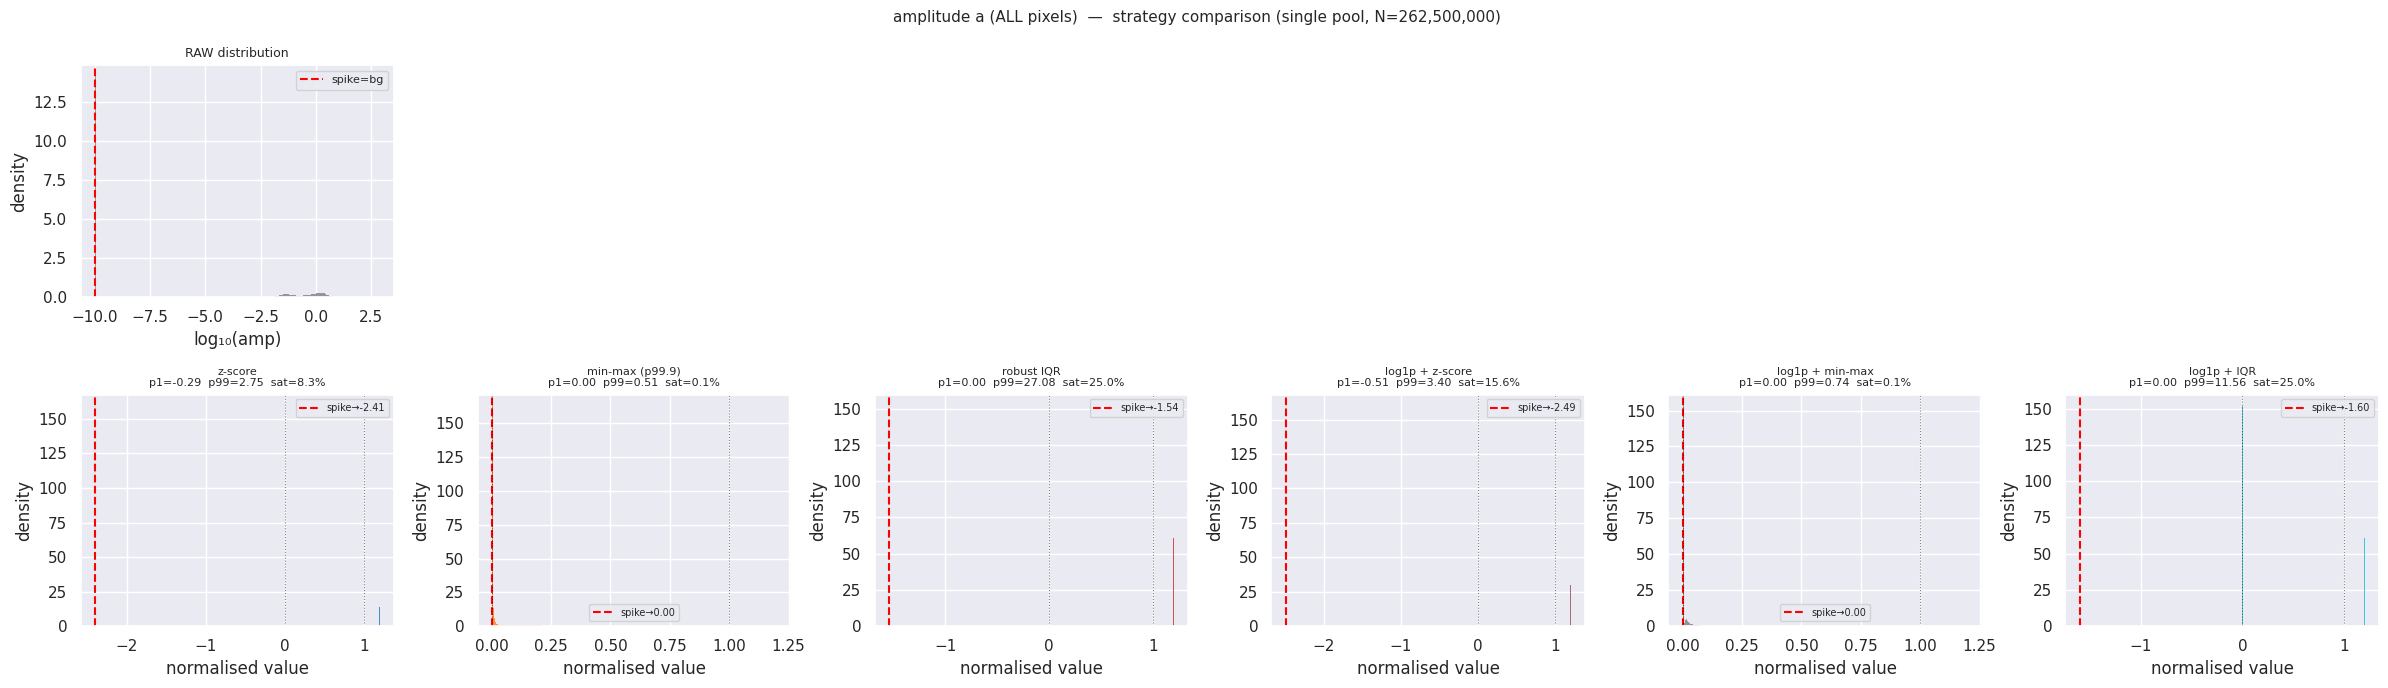


──────────────────────────────────────────────────────────────────────
  mean μ (ACTIVE pixels)
  strategy                 spike_pos       p1      p99     sat%
  ──────────────────────────────────────────────────────────
  z-score                        n/a   -1.124    3.600     3.5%
  min-max (p99.9)                n/a    0.041    0.952     0.0%
  robust IQR                     n/a   -0.864    5.182     7.5%
  log1p + z-score                n/a   -0.688    2.261     0.0%
  log1p + min-max                n/a    0.000    0.986     0.0%
  log1p + IQR                    n/a    0.000    1.830     0.0%


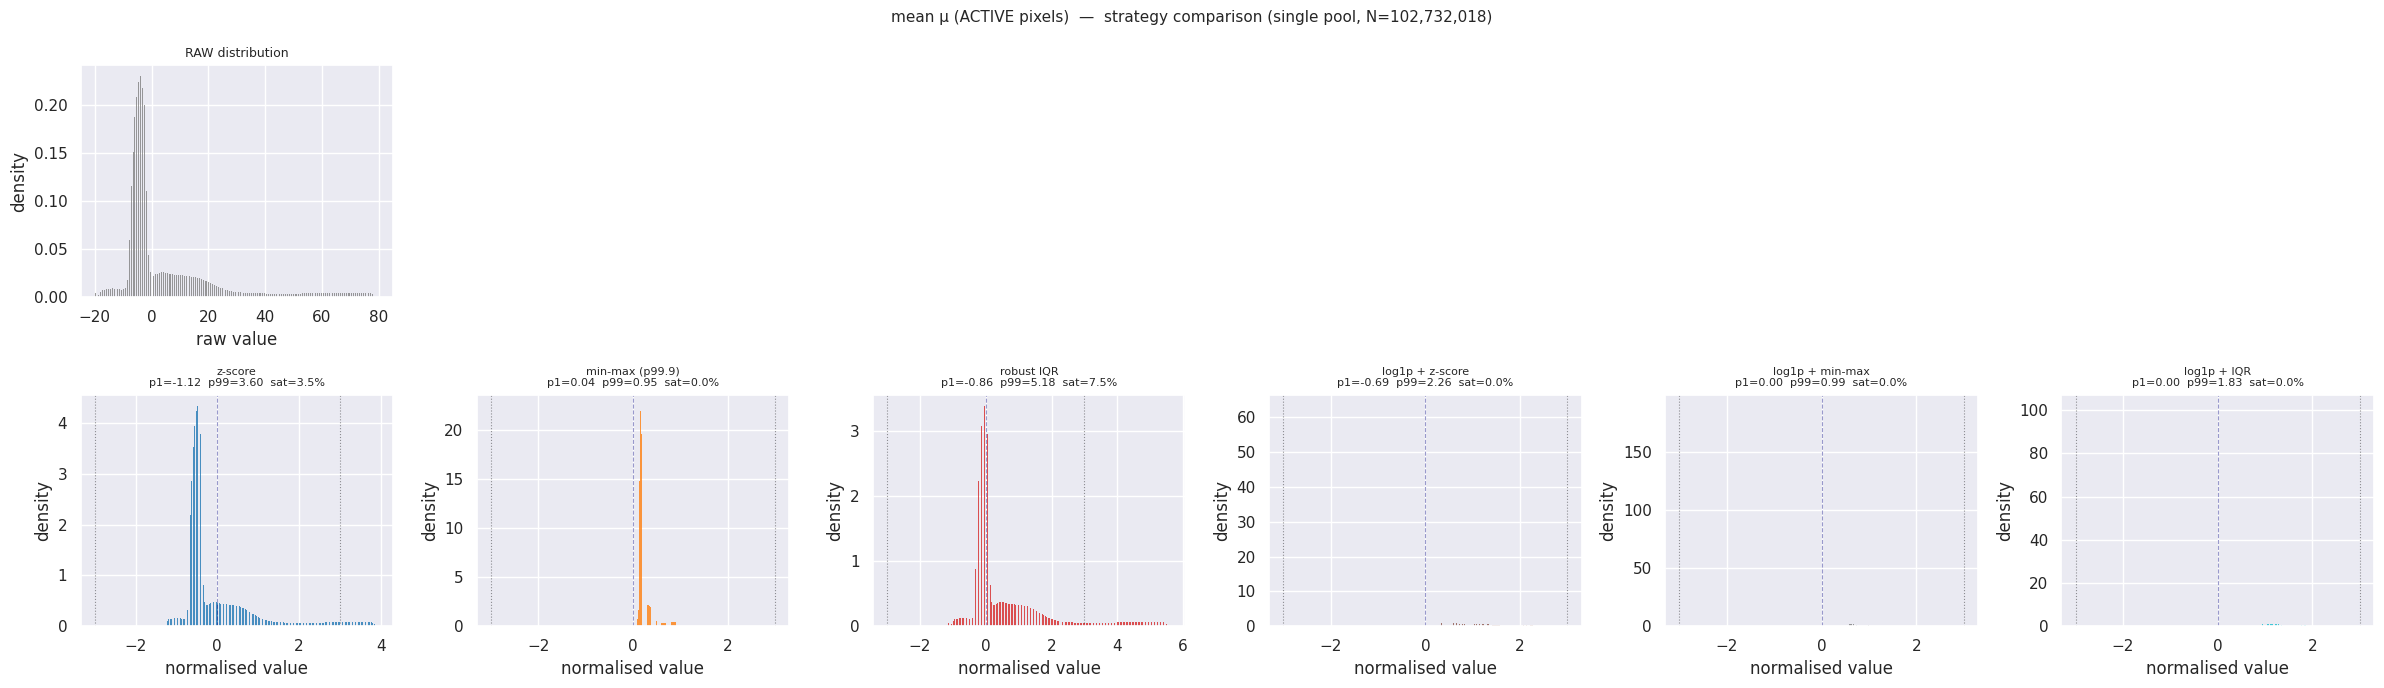


──────────────────────────────────────────────────────────────────────
  sigma σ (ACTIVE pixels)
  strategy                 spike_pos       p1      p99     sat%
  ──────────────────────────────────────────────────────────
  z-score                     -0.703   -0.703    3.434     1.4%
  min-max (p99.9)              0.000    0.000    0.444     0.0%
  robust IQR                  -0.393   -0.393    4.015     2.2%
  log1p + z-score             -1.058   -1.058    2.794     0.7%
  log1p + min-max              0.000    0.000    0.717     0.0%
  log1p + IQR                 -0.515   -0.515    1.955     0.1%


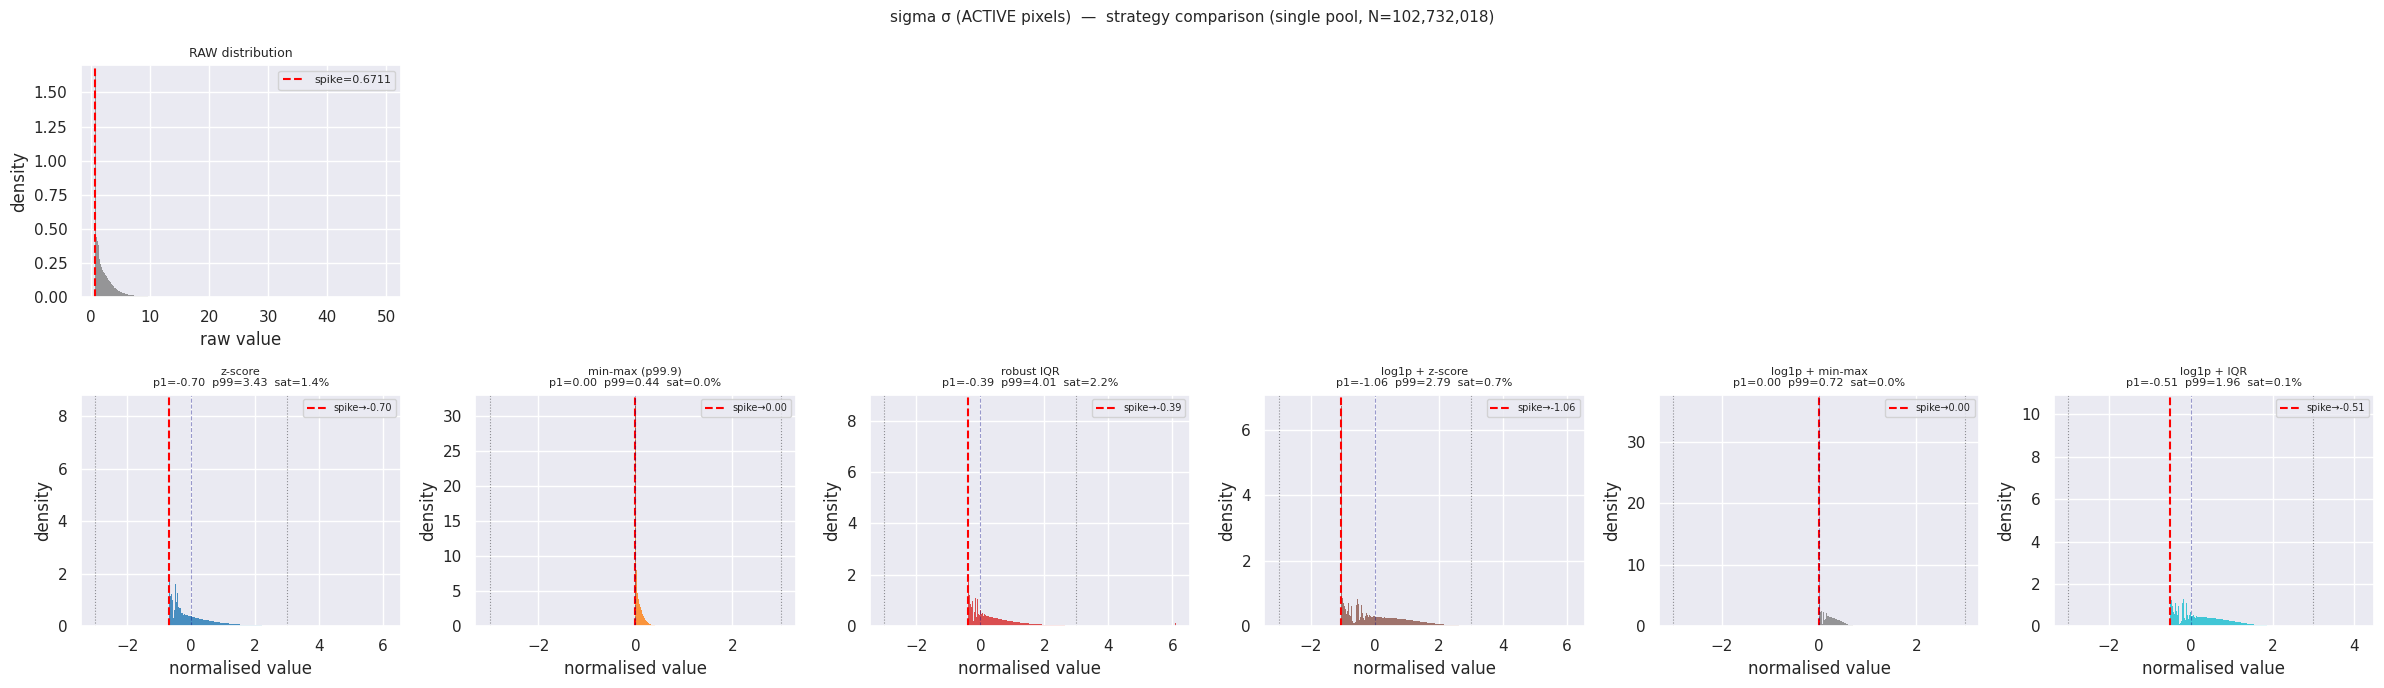

In [21]:
# ── 16 · Strategy search — single pool, spike tracking ───────────────────────
eps = 1e-8
SPIKE_SIGMA = 0.6711   # placeholder sigma value

# ── Single pools ──────────────────────────────────────────────────────────────
amp_all   = np.concatenate([data[k]["amp"] for k in range(n_gaussians)])
mu_act    = np.concatenate([data[k]["mu"][data[k]["active"]]    for k in range(n_gaussians)])
sig_act   = np.concatenate([data[k]["sigma"][data[k]["active"]] for k in range(n_gaussians)])

# ── Strategy definitions: (name, forward_fn, spike_input_value) ──────────────
def _norm_zscore(x):
    return (x - x.mean()) / (x.std() + eps)

def _norm_minmax(x):
    lo, hi = x.min(), np.percentile(x, 99.9)
    return (x - lo) / (hi - lo + eps)

def _norm_iqr(x):
    q25, q75 = np.percentile(x, [25, 75])
    return (x - np.median(x)) / (q75 - q25 + eps)

def _norm_log1p_z(x):
    lx = np.log1p(np.maximum(x, 0))
    return (lx - lx.mean()) / (lx.std() + eps)

def _norm_log1p_minmax(x):
    lx = np.log1p(np.maximum(x, 0))
    lo, hi = lx.min(), np.percentile(lx, 99.9)
    return (lx - lo) / (hi - lo + eps)

def _norm_log1p_iqr(x):
    lx = np.log1p(np.maximum(x, 0))
    q25, q75 = np.percentile(lx, [25, 75])
    return (lx - np.median(lx)) / (q75 - q25 + eps)

strategies = [
    ("z-score",          _norm_zscore),
    ("min-max (p99.9)",  _norm_minmax),
    ("robust IQR",       _norm_iqr),
    ("log1p + z-score",  _norm_log1p_z),
    ("log1p + min-max",  _norm_log1p_minmax),
    ("log1p + IQR",      _norm_log1p_iqr),
]

# ── Plot ──────────────────────────────────────────────────────────────────────
param_configs = [
    # (label,   pool,    spike_raw,  is_amp,  clip_lo, clip_hi, y_label)
    ("amplitude a (ALL pixels)",      amp_all, 0.0,        True,  -0.1, 1.1,  "density"),
    ("mean μ (ACTIVE pixels)",        mu_act,  None,       False, -6,   6,    "density"),
    ("sigma σ (ACTIVE pixels)",       sig_act, SPIKE_SIGMA, False, -6,  6,    "density"),
]

n_strat = len(strategies)
colors_strat = plt.cm.tab10(np.linspace(0, 0.9, n_strat))

for plabel, pool, spike_raw, is_amp, clip_lo, clip_hi, ylbl in param_configs:
    fig, axes = plt.subplots(2, n_strat, figsize=(4 * n_strat, 7), squeeze=False)
    fig.suptitle(f"{plabel}  —  strategy comparison (single pool, N={len(pool):,})", fontsize=11)

    # ── Top row: raw distribution + spike marker ──────────────────────────
    ax_raw = axes[0, 0]
    raw_plot = np.log10(pool + 1e-10) if is_amp else pool
    ax_raw.hist(raw_plot, bins=300, density=True, color="grey", alpha=0.8, edgecolor="none")
    if spike_raw is not None:
        sv = np.log10(spike_raw + 1e-10) if (is_amp and spike_raw == 0.0) else spike_raw
        ax_raw.axvline(sv, color="red", lw=1.5, linestyle="--",
                       label=f"spike={'bg' if is_amp else f'{spike_raw}'}")
        ax_raw.legend(fontsize=8)
    ax_raw.set_title("RAW distribution", fontsize=9)
    ax_raw.set_xlabel("log₁₀(amp)" if is_amp else "raw value")
    ax_raw.set_ylabel("density")
    for col in range(1, n_strat):
        axes[0, col].set_visible(False)

    # ── Bottom row: one subplot per strategy ─────────────────────────────
    print(f"\n{'─'*70}")
    print(f"  {plabel}")
    print(f"  {'strategy':<22}  {'spike_pos':>10}  {'p1':>7}  {'p99':>7}  {'sat%':>7}")
    print(f"  {'─'*58}")

    for col, (sname, sfn) in enumerate(strategies):
        ax = axes[1, col]
        col_c = colors_strat[col]

        normed  = sfn(pool)
        clipped = np.clip(normed, clip_lo - 0.1, clip_hi + 0.1)

        ax.hist(clipped, bins=300, density=True, color=col_c, alpha=0.8, edgecolor="none")

        # Mark where the spike lands after normalisation
        spike_pos = None
        if spike_raw is not None:
            if is_amp:
                # background spike: spike_raw=0.0 → normalise a single 0
                spike_pos = float(sfn(np.array([0.0, *pool[:100]]))[0])
            else:
                # sigma placeholder: find pixels closest to SPIKE_SIGMA
                ph_mask = np.abs(pool - spike_raw) < 0.005
                if ph_mask.any():
                    spike_pos = float(np.median(normed[ph_mask]))

        if spike_pos is not None:
            ax.axvline(spike_pos, color="red", lw=1.5, linestyle="--",
                       label=f"spike→{spike_pos:.2f}")
            ax.legend(fontsize=7)

        # Reference lines
        if is_amp:
            ax.axvline(0, color="black", lw=0.8, linestyle=":", alpha=0.5)
            ax.axvline(1, color="black", lw=0.8, linestyle=":", alpha=0.5)
            sat = 100.0 * (normed > 1.0).mean()
        else:
            ax.axvline(-3, color="black", lw=0.8, linestyle=":", alpha=0.4)
            ax.axvline( 3, color="black", lw=0.8, linestyle=":", alpha=0.4)
            ax.axvline( 0, color="navy",  lw=0.8, linestyle="--", alpha=0.4)
            sat = 100.0 * ((normed < -3) | (normed > 3)).mean()

        p1  = float(np.percentile(normed, 1))
        p99 = float(np.percentile(normed, 99))
        ax.set_title(f"{sname}\np1={p1:.2f}  p99={p99:.2f}  sat={sat:.1f}%", fontsize=8)
        ax.set_xlabel("normalised value")
        ax.set_ylabel(ylbl)

        sp_str = f"{spike_pos:.3f}" if spike_pos is not None else "  n/a"
        print(f"  {sname:<22}  {sp_str:>10}  {p1:>7.3f}  {p99:>7.3f}  {sat:>6.1f}%")

    fig.tight_layout()
    plt.show()
